# Soil Moisture Forecasting with ConvLSTM

## 1. Problem Description

- **Task**:
    Predict future soil moisture (`sm_30cm`) using past observations.

- **Input**:
    Multivariate daily time series (len(features) variables).

- **Output**:
    Soil moisture at a specific depth for the next `horizon` days.

- **Data structure**:
    Multiple CSV files, each containing data from one region, further divided by `probe_name`.

---

## 2. Input Variables

Each daily record contains the following **7 input variables**:

## 3. Model Input / Output Definition

### Input (X)

For each sample, the model receives:

- The past **`window` days** of observations
- Shape:
X.shape = (N_samples, window, 1, 7, 1)

This follows the ConvLSTM2D input format: (batch, time, rows, cols, channels)

Where:
- `window` = lookback length (e.g. 14 or 30 days)
- `7` = number of input variables

---

### Output (Y)

- Prediction for the requested horizon
- Shape:

Y.shape = (N_samples, horizon)

- Represents soil moisture (`sm_xcm`) for the next day(s).

## ConvLSTM 
Flatten 7 variables into a 1x7x1 "pseudo-spatial grid"

Input shape: (batch, time, 1, 7, 1)

Output: (batch, horizon) of sm_30cm(t+1 to t+horizon)

Spatial split (by files/stations): train/val/test = 70%/15%/15%

Train with train, early stop / adjust learning rate with val

Evaluate metrics (MAE / RMSE) on test

Output simultaneously: sm_30cm prediction for the next day (t+1) after the last date in each test file

Must save:
1️⃣ Model (ConvLSTM weights + structure)
2️⃣ X scaler
3️⃣ y scaler

In [1]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 23.6 MB/s eta 0:00:00


In [2]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from typing import Dict, Tuple, List

from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import lightgbm as lgb
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanSquaredError as MSE
from tensorflow.keras.regularizers import l2

In [3]:
# mount drive if colab
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
# ============================================================
# Configuration
# ============================================================

ROOT_DIR = "/content/gdrive/MyDrive/NIFA_Download/dataset_training"
FOLDER_NAME = "csv_meteo_and_soil"    
base_path = os.path.join(ROOT_DIR, FOLDER_NAME, "depth")

# Input features (On utilise 'soil_moisture' pour Soil Moisture, et les variables météo)
FEATURE_COLS =  [ "IRRAD", "TMIN", "TMAX", "VAP", "WIND", "RAIN",
"clay_m_30m_0cm_30cm", "silt_m_30m_0cm_30cm", "bulk_m_30m_0cm_30cm", "ksat_m_1km_0cm", "dem_aspect", "dem_twi"] # + doy_sin_cos pour la saisonnalité

#    ["soil_moisture", "IRRAD", "TMIN", "TMAX", "VAP", "WIND", "RAIN",
# "dem_m_30m_depth", "clay_m_30m_0cm_30cm", "silt_m_30m_0cm_30cm", "sand_m_30m_0cm_30cm", "Saturation",
# "bulk_m_30m_0cm_30cm", "ksat_m_1km_0cm", "dem_slope", "dem_aspect", "dem_twi"] 

TARGET_COL = "soil_moisture"
DATE_COL = "DateTime"  # L'index temporel est sauvegardé sous DateTime par process_timeseries

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15           # remaining 0.15 is test

# Training settings
HORIZONS = [7]              # predict * days ahead 
LOOKBACK = [7, 14]              # use past * days to predict next day
EPOCHS = 150
BATCH_SIZE = 32
SEED = 8
DEPTHS = [0.1]  # we will loop over these depths and train one model per depth
# NB_INPUT_FILES = [30]
NB_WINDOWS = [500, 1000, 5000, 10000]  # number of windows to sample for training (for DL models, we will try with 500, 1000, and 2000)
# Deep Learning models: lstm, transformer, convlstm, xgboost, random_forest ... lightgbm, svr
MODELS = ["lstm", "gru", "tcn", "xgboost", "lightgbm", "transformer"]
MAX_BLOCKS = 1  # for convlstm, we will try with 1, 2, and 3 blocks

drive_dir = os.path.join("/content/gdrive/MyDrive/NIFA_Download/outputs", FOLDER_NAME, "test_pca")
os.makedirs(drive_dir, exist_ok=True)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
# ============================================================
# Results CSV Configuration
# ============================================================

RESULTS_CSV_PATH = os.path.join("/content/gdrive/MyDrive/NIFA_Download/outputs", FOLDER_NAME, "results.csv")

def save_to_results_csv(
    results_dict: Dict,
    csv_path: str = RESULTS_CSV_PATH
) -> None:
    """
    Sauvegarde les résultats dans un CSV centralisé en mode append.
    
    Args:
        results_dict : Dictionnaire avec les colonnes à sauvegarder
        csv_path : Chemin du fichier CSV cible
    
    Structure des colonnes:
        timestamp | type | depth | lookback | horizon | nb_windows | model | chunk | file_id | 
        features | metric_name | value | notes
    
    Types possibles: GLOBAL, DETAILED, GRANDVILLERS, CROSSVAL
    """
    import os
    from datetime import datetime
    
    # Créer le dossier si nécessaire
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    
    # Ajouter timestamp automatiquement
    results_dict['timestamp'] = datetime.now().strftime('%Y-%m-%d_%H:%M:%S')

    # Ajouter les features automatiquement si non spécifiées, en utilisant la variable globale FEATURE_COLS
    if 'features' not in results_dict:
        results_dict['features'] = ",".join(FEATURE_COLS)
    
    # Colonnes standard (certaines peuvent être vides selon le type)
    columns = [
        'timestamp', 'features', 'type', 'depth', 'lookback', 'horizon', 'nb_windows', 
        'model', 'chunk', 'file_id', 'metric_name', 'value', 'notes'
    ]
    
    # Créer une nouvelle ligne avec les colonnes manquantes remplies de None
    row_dict = {col: results_dict.get(col, None) for col in columns}
    row_df = pd.DataFrame([row_dict])
    
    # Append au CSV existant ou créer nouveau
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        df_new = pd.concat([df_existing, row_df], ignore_index=True)
    else:
        df_new = row_df
    
    df_new.to_csv(csv_path, index=False)
    print(f"✓ Résultat sauvegardé: {results_dict.get('type', '?')} - {results_dict.get('metric_name', '?')} = {results_dict.get('value', '?')}")

In [6]:
def load_csv(csv_path: str) -> pd.DataFrame:
    """
    Load CSV and keep only required columns.
    This matches the 'data preparation' step used in the reference idea:
    clean -> sort by time -> build sequences.
    """
    df = pd.read_csv(csv_path)
    
    # Gérer la colonne date qui peut s'appeler 'date' ou 'DateTime' selon la sauvegarde
    if 'date' in df.columns:
        df = df.rename(columns={'date': DATE_COL})
    if 'Unnamed: 0' in df.columns and DATE_COL not in df.columns:
        df = df.rename(columns={'Unnamed: 0': DATE_COL})

    # Basic schema checks
    if DATE_COL not in df.columns:
        raise ValueError(f"[{csv_path}] Missing required column: {DATE_COL}")

    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"[{csv_path}] Missing feature columns: {missing}")

    if TARGET_COL not in df.columns:
        raise ValueError(f"[{csv_path}] Missing target column: {TARGET_COL}")

    # Parse dates and numeric columns
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df = df.dropna(subset=[DATE_COL]).copy()

    # Add cyclical encoding for day of year (to capture seasonality)
    day_of_year = df[DATE_COL].dt.dayofyear
    df['doy_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)

    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

    # Keep only relevant columns
    cols_to_keep = [DATE_COL] + FEATURE_COLS + ['doy_sin', 'doy_cos']
    if TARGET_COL not in cols_to_keep:
        cols_to_keep.append(TARGET_COL)
    df = df[cols_to_keep].copy()

    # Sort to preserve time order
    df = df.sort_values([DATE_COL]).reset_index(drop=True)
    return df

In [7]:
def get_file_paths(files_path : str) -> List[str]:
    """Retourne la taille (nombre de lignes) de chaque fichier."""
    file_paths = []

    # Lister tous les fichiers dans le dossier
    for filename in os.listdir(files_path):
        if filename.endswith('.csv'):
            full_path = os.path.join(files_path, filename)
            file_paths.append(full_path)
    return file_paths

In [8]:
def split_spatial_files(file_paths: List[str], lookback: int, horizon: int) -> Tuple[List[pd.DataFrame], List[pd.DataFrame], List[pd.DataFrame]]:
    
    shuffled_indices = np.random.permutation(len(file_paths))
    n = len(file_paths)
    n_train = int(n * 0.7)
    n_val = int(n * 0.15)

    train_indices = shuffled_indices[:n_train]
    val_indices = shuffled_indices[n_train:n_train + n_val]
    test_indices = shuffled_indices[n_train + n_val:]

    train_list = []
    for indices in train_indices :
        # Utiliser load_csv au lieu de pd.read_csv pour nettoyer les NaNs et filtrer les colonnes
        file = load_csv(file_paths[indices])
        # Drop strict des NaNs pour Scikit-Learn (sinon ValueError: Input contains NaN)
        file = file.dropna(subset=[DATE_COL] + FEATURE_COLS + [TARGET_COL])
        
        if len(file) < lookback + horizon + 1:
            print(f"Warning: File {file_paths[indices]} is too short ({len(file)} rows) and will be skipped.")
            continue
        train_list.append(file)

    val_list = []
    for indices in val_indices :
        file = load_csv(file_paths[indices])
        file = file.dropna(subset=[DATE_COL] + FEATURE_COLS + [TARGET_COL])
        if len(file) < lookback + horizon + 1:
            print(f"Warning: File {file_paths[indices]} is too short ({len(file)} rows) and will be skipped.")
            continue
        val_list.append(file)

    test_list = []
    for indices in test_indices :
        file = load_csv(file_paths[indices])
        file = file.dropna(subset=[DATE_COL] + FEATURE_COLS + [TARGET_COL])
        if len(file) < lookback + horizon + 1:
            print(f"Warning: File {file_paths[indices]} is too short ({len(file)} rows) and will be skipped.")
            continue
        test_list.append(file)

    return train_list, val_list, test_list

In [9]:
def make_supervised(
    df_list: List[pd.DataFrame],
    scaler_x: StandardScaler,
    scaler_y: StandardScaler,
    fit: bool,
    lookback: int,
    horizon: int,
    format: str,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    
   
    """
    Construit les tenseurs X et y avec le format adapté au modèle.
    """

    if fit:
        # Fit scaler first on all training data using partial_fit
        for df in df_list:
            X_raw = df[FEATURE_COLS].values.astype(np.float32)
            y_raw = df[[TARGET_COL]].values.astype(np.float32)
            scaler_x.partial_fit(X_raw)
            scaler_y.partial_fit(y_raw)

    X_list, y_list, d_list = [], [], []
    for df in df_list:
        X_raw = df[FEATURE_COLS].values.astype(np.float32)
        y_raw = df[[TARGET_COL]].values.astype(np.float32)
        dates = df[DATE_COL].values

        Xs = scaler_x.transform(X_raw)
        ys = scaler_y.transform(y_raw).reshape(-1)

        for i in range(lookback, len(df) - horizon + 1):
            window = Xs[i - lookback:i, :]  # Shape: (lookback, features)
            
            if format.lower() in ["convlstm","lstm", "transformer", "gru", "tcn"]:
                X_list.append(window) # RNN/Transformer attendent du 3D
            else:  # Modèles ML (XGBoost, RandomForest)
                X_list.append(window.flatten()) # Aplatit en 1D

            y_list.append(ys[i:i + horizon])
            d_list.append(dates[i])         

    X = np.array(X_list, dtype=np.float32)            
    y = np.array(y_list, dtype=np.float32)
    d = np.array(d_list)

    # Le ConvLSTM2D Keras attend une forme spécifique en 5D
    if format.lower() == "convlstm":
        X = X.reshape(X.shape[0], lookback, 1, len(FEATURE_COLS), 1)
        
    return X, y, d

In [10]:
def build_xgboost(horizon: int) -> XGBRegressor:
    """Modèle XGBoost pour multi-horizon forecasting"""
    return XGBRegressor(
        n_estimators=200,
        max_depth=7,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1,
        tree_method='hist',
        early_stopping_rounds=20,
    )

def build_random_forest(horizon: int) -> RandomForestRegressor:
    """Modèle Random Forest pour multi-horizon forecasting"""
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    )

def build_lightgbm(horizon: int) -> MultiOutputRegressor:
    base = lgb.LGBMRegressor(
        n_estimators=200, max_depth=7, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    return MultiOutputRegressor(base)

In [11]:
def build_convlstm(lookback: int, width: int, horizon: int) -> tf.keras.Model:
    """
    ConvLSTM backbone (inspired by the reference repo's ConvLSTM forecasting idea).
    """
    inp = layers.Input(shape=(lookback, 1, width, 1))

    x = layers.ConvLSTM2D(
        filters=16,
        kernel_size=(1, 3),
        padding="same",
        return_sequences=True,
        activation="tanh",
        kernel_regularizer=l2(1e-4),
    )(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.ConvLSTM2D(
        filters=16,
        kernel_size=(1, 3),
        padding="same",
        return_sequences=False,
        activation="tanh",
        kernel_regularizer=l2(1e-4),
    )(x)
    x = layers.BatchNormalization()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(horizon, activation="linear")(x)
    
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model


def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Mécanisme de Self-Attention
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(inputs + x)
    
    # Réseau Feed-Forward
    res = layers.Dense(ff_dim, activation="relu")(x)
    res = layers.Dropout(dropout)(res)
    res = layers.Dense(inputs.shape[-1])(res)
    
    return layers.LayerNormalization(epsilon=1e-6)(x + res)

def build_transformer(lookback: int, width: int, horizon: int, head_size=64, num_heads=4, ff_dim=64, num_layers=2, dropout=0.1) -> tf.keras.Model:
    """Transformer direct sur (lookback, features)"""
    inp = layers.Input(shape=(lookback, width))  # ← Changé ici
    
    # Plus besoin de Reshape !
    x = layers.Dense(head_size)(inp)
    
    for _ in range(num_layers):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(horizon, activation="linear")(x)
    
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model


def build_lstm(lookback: int, width: int, horizon: int) -> tf.keras.Model:
    """LSTM sur (lookback, features)"""
    inp = layers.Input(shape=(lookback, width))
    
    x = layers.LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-4))(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(32, return_sequences=False, kernel_regularizer=l2(1e-4))(x)
  
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(horizon, activation="linear")(x)
    
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model

def build_gru(lookback: int, width: int, horizon: int) -> tf.keras.Model:
    inp = layers.Input(shape=(lookback, width))
    x = layers.GRU(128, return_sequences=True, kernel_regularizer=l2(1e-4))(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.GRU(64, return_sequences=True, kernel_regularizer=l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.GRU(32, return_sequences=False, kernel_regularizer=l2(1e-4))(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(horizon, activation="linear")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model

def build_tcn(lookback: int, width: int, horizon: int) -> tf.keras.Model:
    inp = layers.Input(shape=(lookback, width))
    x = layers.Conv1D(64, kernel_size=3, padding="causal", dilation_rate=1, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv1D(64, kernel_size=3, padding="causal", dilation_rate=2, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv1D(32, kernel_size=3, padding="causal", dilation_rate=4, activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(horizon, activation="linear")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model

In [12]:
def inverse_y(scaler_y: StandardScaler, y_scaled_2d: np.ndarray) -> np.ndarray:
    """Inverse-transform a 2D array (N, horizon) back to original units."""
    flat = y_scaled_2d.reshape(-1, 1)
    inv = scaler_y.inverse_transform(flat).reshape(y_scaled_2d.shape)
    return inv

In [13]:
def plot_loss(history: tf.keras.callbacks.History, out_png: str, title: str) -> None:
    """Plot train/validation loss curves (single figure)."""
    plt.figure()
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss (MSE on scaled y)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()

In [14]:
def plot_test_true_vs_pred(dates, y_true, y_pred_local, y_pred_era5=None, out_png: str="", title: str="") -> None:
    """Plot test series: actual vs prediction (handles both Local and optionally ERA5 logic)."""
    plt.figure(figsize=(10, 5))
    plt.plot(dates, y_true, label="Actual", color='black', alpha=0.7)
    plt.plot(dates, y_pred_local, label="Prediction (Local)", color='tab:blue')
    
    if y_pred_era5 is not None:
        plt.plot(dates, y_pred_era5, label="Prediction (ERA5)", color='tab:orange', linestyle='--')
        
    plt.xlabel("Date")
    plt.ylabel("Soil Moisture (m3/m3)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()

In [15]:
def train_eval_predict_one_probe(
    file_paths: list,
    drive_dir: str,
    lookback: int,
    horizon: int,
    choose_model: str,
    save_test_plots: str,
    max_windows: int = None,
) -> Tuple[float, float, float]:
    # 1. Split spatial des fichiers
    train_list, val_list, test_list = split_spatial_files(file_paths, lookback, horizon)
    print(f"Spatial split: train={len(train_list)} files, val={len(val_list)} files, test={len(test_list)} files")
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    is_dl = choose_model in ["convlstm", "lstm", "transformer", "gru", "tcn"]
    model_format = choose_model.lower()
    # 2. Données d'entraînement avec subsampling par fenêtres
    X_train, y_train, _ = make_supervised(
        train_list, scaler_x, scaler_y, fit=True,
        lookback=lookback, horizon=horizon, format=model_format
    )
    if max_windows is not None and len(X_train) > max_windows:
        idx = np.random.choice(len(X_train), max_windows, replace=False)
        X_train, y_train = X_train[idx], y_train[idx]
        print(f"Subsampled to {max_windows} training windows")
    else:
        print(f"Using all {len(X_train)} training windows")
    X_val, y_val, _ = make_supervised(
        val_list, scaler_x, scaler_y, fit=False,
        lookback=lookback, horizon=horizon, format=model_format
    )
    # 3. Modèle
    if choose_model == "convlstm":
        model = build_convlstm(lookback, len(FEATURE_COLS), horizon=horizon)
    elif choose_model == "transformer":
        model = build_transformer(lookback, len(FEATURE_COLS), horizon=horizon)
    elif choose_model == "lstm":
        model = build_lstm(lookback, len(FEATURE_COLS), horizon=horizon)
    elif choose_model == "xgboost":
        model = build_xgboost(horizon=horizon)
    elif choose_model == "gru":
        model = build_gru(lookback, len(FEATURE_COLS), horizon=horizon)
    elif choose_model == "tcn":
        model = build_tcn(lookback, len(FEATURE_COLS), horizon=horizon)
    elif choose_model == "lightgbm":
        model = build_lightgbm(horizon=horizon)
    elif choose_model == "random_forest":
        print("Lancement de l'optimisation Optuna pour Random Forest...")
        def objective(trial):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 50, 300, step=50),
                "max_depth": trial.suggest_int("max_depth", 5, 25),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
            }
            m = RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
            m.fit(X_train, y_train)
            return np.sqrt(mean_squared_error(y_val, m.predict(X_val)))
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=10)
        print(f"Best params: {study.best_params}, Best val RMSE: {study.best_value:.4f}")
        model = RandomForestRegressor(**study.best_params, random_state=SEED, n_jobs=-1)
    else:
        raise ValueError(f"Unknown model type: {choose_model}")
    # 4. Paths
    try:
        model_ext = "keras" if is_dl else "pkl"
        model_path = os.path.join(drive_dir, f"model.{model_ext}")
        scaler_x_path = os.path.join(drive_dir, "scaler_x.pkl")
        scaler_y_path = os.path.join(drive_dir, "scaler_y.pkl")
        history_csv = os.path.join(drive_dir, "history.csv")
        loss_png = os.path.join(drive_dir, "loss_train_val.png")
    except Exception as e:
        print(f"Could not setup output paths: {e}")
    print(f"Samples: train={len(X_train)}, val={len(X_val)}  (lookback={lookback})")
    # 5. Entraînement
    if is_dl:
        cbs = [
            callbacks.ModelCheckpoint(model_path, monitor="val_loss", save_best_only=True),
            callbacks.EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5),
            callbacks.CSVLogger(history_csv, append=False),
        ]
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            shuffle=True, callbacks=cbs, verbose=1
        )
        model.save(model_path)
        plot_loss(history, loss_png, title=f"Loss: {choose_model}")
    elif choose_model == "xgboost" :
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        joblib.dump(model, model_path)
    elif choose_model == "lightgbm" :
        model.fit(X_train, y_train)
        joblib.dump(model, model_path)
    
    else:
        model.fit(X_train, y_train)
        joblib.dump(model, model_path)
    joblib.dump(scaler_x, scaler_x_path)
    joblib.dump(scaler_y, scaler_y_path)
    # 6. Test evaluation
    mae_mean, rmse_mean, mape_mean = 0.0, 0.0, 0.0
    for i, df_test in enumerate(test_list):
        if len(df_test) < lookback + 1:
            print(f"Test file {i} too short, skipping.")
            continue
        X_test, y_test, d_test = make_supervised(
            [df_test], scaler_x, scaler_y, fit=False,
            lookback=lookback, horizon=horizon, format=model_format
        )
        if len(X_test) == 0:
            continue
        y_pred_test_scaled = model.predict(X_test, verbose=0) if is_dl else model.predict(X_test)
        y_true = inverse_y(scaler_y, y_test)
        y_pred = inverse_y(scaler_y, y_pred_test_scaled)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        denom = np.maximum(np.abs(y_true), 1e-8)
        mape = float(np.mean(np.abs((y_pred - y_true) / denom)) * 100.0)
        mae_mean += mae
        rmse_mean += rmse
        mape_mean += mape
        print(f"[TEST File {i}] MAE={mae:.6f} RMSE={rmse:.6f} MAPE={mape:.2f}%")
        if save_test_plots == "first_last":
            horizons_to_plot = [0, horizon - 1]
        elif save_test_plots == "all":
            horizons_to_plot = range(horizon)
        else:
            horizons_to_plot = []
        for j in horizons_to_plot:
            test_png = os.path.join(drive_dir, f"test_true_vs_pred_file_{i}_horizon_{j}.png")
            plot_test_true_vs_pred(
                pd.to_datetime(d_test), y_true[:, j],
                y_pred_local=y_pred[:, j],
                out_png=test_png,
                title=f"Test True vs Pred File {i} horizon {j} ({len(d_test)} samples)"
            )
    if len(test_list) > 0:
        mae_mean /= len(test_list)
        rmse_mean /= len(test_list)
        mape_mean /= len(test_list)
    print(f"Saved outputs to: {drive_dir}")
    return mae_mean, rmse_mean, mape_mean

In [16]:
# # ============================================================
# # Training / Evaluation per probe
# # ============================================================
# def train_eval_predict_one_probe(
#     file_paths: list, 
#     drive_dir: str, 
#     lookback: int, 
#     horizon: int, 
#     choose_model: str,
#     save_test_plots: str,
# ) -> Tuple[float, float, float]:
    
#     # 1. On sépare d'abord les fichiers
#     train_list, val_list, test_list = split_spatial_files(file_paths, lookback, horizon)
#     print(f"Spatial split: train={len(train_list)} files, val={len(val_list)} files, test={len(test_list)} files")
    
#     scaler_x = StandardScaler()
#     scaler_y = StandardScaler()

#     # 2. On détermine le format à réclamer à make_supervised
#     is_dl = choose_model in ["convlstm", "lstm", "transformer"]
#     model_format = choose_model.lower() # sera passé comme format

#     # 3. Préparation des données d'entraînement 
#     X_train, y_train, _ = make_supervised(train_list, scaler_x, scaler_y, fit=True, lookback=lookback, horizon=horizon, format=model_format)
#     X_val, y_val, _ = make_supervised(val_list, scaler_x, scaler_y, fit=False, lookback=lookback, horizon=horizon, format=model_format)
    
#     # 4. Instanciation du modèle
#     if choose_model == "convlstm":
#         model = build_convlstm(lookback, len(FEATURE_COLS), horizon=horizon)
#     elif choose_model == "transformer":
#         model = build_transformer(lookback, len(FEATURE_COLS), horizon=horizon)
#     elif choose_model == "lstm":
#         model = build_lstm(lookback, len(FEATURE_COLS), horizon=horizon)
#     elif choose_model == "xgboost":
#         model = build_xgboost(horizon=horizon)
#     elif choose_model == "random_forest":
        
#         print("Lancement de l'optimisation Optuna pour Random Forest...")
#         def objective(trial):
#             rf_n_estimators = trial.suggest_int("n_estimators", 50, 300, step=50)
#             rf_max_depth = trial.suggest_int("max_depth", 5, 25)
#             rf_min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
            
#             trial_model = RandomForestRegressor(
#                 n_estimators=rf_n_estimators,
#                 max_depth=rf_max_depth,
#                 min_samples_split=rf_min_samples_split,
#                 random_state=SEED,
#                 n_jobs=-1
#             )
#             trial_model.fit(X_train, y_train)
#             preds = trial_model.predict(X_val)
            
#             # Retourne la RMSE sur le set de validation (MSE -> sqrt)
#             rmse_val = np.sqrt(mean_squared_error(y_val, preds))
#             return rmse_val

#         # Création et exécution de l'étude (on cache les logs trop verbeux si on veut mais Optuna gère ça)
#         optuna.logging.set_verbosity(optuna.logging.WARNING)
#         study = optuna.create_study(direction="minimize")
#         study.optimize(objective, n_trials=10) # 10 essais pour un test rapide
        
#         print(f"Meilleurs hyperparamètres trouvés: {study.best_params}")
#         print(f"Meilleure RMSE de validation: {study.best_value:.4f}")
        
#         # Le modèle final est instancié avec les meilleurs paramètres
#         model = RandomForestRegressor(**study.best_params, random_state=SEED, n_jobs=-1)
#     else:
#         raise ValueError(f"Unknown model type: {choose_model}")

#     # 5. Définition des chemins
#     try:
#         model_ext = "keras" if is_dl else "pkl"
#         model_path = os.path.join(drive_dir, f"model.{model_ext}")
#         scaler_x_path = os.path.join(drive_dir, "scaler_x.pkl")
#         scaler_y_path = os.path.join(drive_dir, "scaler_y.pkl")
#         history_csv = os.path.join(drive_dir, "history.csv")
#         loss_png = os.path.join(drive_dir, "loss_train_val.png")
#     except Exception as e:
#         print(f"Could not setup output paths: {e}")

#     print(f"Samples: train={len(X_train)}, val={len(X_val)}  (lookback={lookback})")

#     # 6. Entraînement et sauvegarde
#     if is_dl:
#         cbs = [
#             callbacks.ModelCheckpoint(model_path, monitor="val_loss", save_best_only=True),
#             callbacks.EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True),
#             callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5),
#             callbacks.CSVLogger(history_csv, append=False),
#         ]

#         history = model.fit(
#             X_train, y_train,
#             validation_data=(X_val, y_val),
#             epochs=EPOCHS,
#             batch_size=BATCH_SIZE,
#             shuffle=True,
#             callbacks=cbs,
#             verbose=1
#         )
#         model.save(model_path)
#         plot_loss(history, loss_png, title=f"Loss: {choose_model}")
#     elif choose_model == "xgboost":
#         model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
#         joblib.dump(model, model_path)
#     else:
#         # Entraînement Scikit-learn/XGBoost classique
#         model.fit(X_train, y_train)
#         joblib.dump(model, model_path)

#     joblib.dump(scaler_x, scaler_x_path)
#     joblib.dump(scaler_y, scaler_y_path)

#     # ------------------------------------------------------------
#     # Test evaluation (per file in test_list)
#     # ------------------------------------------------------------
#     mae_mean, rmse_mean, mape_mean = 0.0, 0.0, 0.0
    
#     for i, df_test in enumerate(test_list):
#         if len(df_test) < lookback + 1:
#             print(f"Test file {i} too short, skipping.")
#             continue
            
#         # Appel de make_supervised avec le bon format pour le test aussi
#         X_test, y_test, d_test = make_supervised([df_test], scaler_x, scaler_y, fit=False, lookback=lookback, horizon=horizon, format=model_format)
#         if len(X_test) == 0:
#             continue
            
#         if is_dl:
#             y_pred_test_scaled = model.predict(X_test, verbose=0)
#         else:
#             y_pred_test_scaled = model.predict(X_test)
            
#         y_true = inverse_y(scaler_y, y_test)                      
#         y_pred = inverse_y(scaler_y, y_pred_test_scaled)          

#         mae = mean_absolute_error(y_true, y_pred)
#         rmse = np.sqrt(mean_squared_error(y_true, y_pred))

#         denom = np.maximum(np.abs(y_true), 1e-8)
#         mape = float(np.mean(np.abs((y_pred - y_true) / denom)) * 100.0)

#         mae_mean += mae
#         rmse_mean += rmse
#         mape_mean += mape

#         print(f"[TEST File {i}] MAE={mae:.6f} RMSE={rmse:.6f} MAPE={mape:.2f}%")

#          # Plot test curve
#         if save_test_plots == "first_last":
#             horizons_to_plot = [0, horizon - 1]
#         elif save_test_plots == "all":
#             horizons_to_plot = range(horizon)
#         else:
#             horizons_to_plot = []

#         for j in horizons_to_plot:
#             test_png = os.path.join(drive_dir, f"test_true_vs_pred_file_{i}_horizon_{j}.png")
#             plot_test_true_vs_pred(
#                 pd.to_datetime(d_test),
#                 y_true[:, j],
#                 y_pred_local=y_pred[:, j],
#                 out_png=test_png,
#                 title=f"Test True vs Pred File {i} horizon {j} ({len(d_test)} samples)"
#             )

#     if len(test_list) > 0:
#         mae_mean /= len(test_list)
#         rmse_mean /= len(test_list)
#         mape_mean /= len(test_list)    
    
#     print(f"Saved outputs to: {drive_dir}")
#     return mae_mean, rmse_mean, mape_mean

In [17]:

def full_training(DEPTHS, LOOKBACK, HORIZONS, NB_WINDOWS, MODELS, base_path, drive_dir, n_trials=1):
    for d in DEPTHS:
        print(f"\n====================== NEW DEPTH: {d} ======================")
        base_path_d = base_path + "_" + str(d)
        all_file_paths = get_file_paths(base_path_d)
        all_file_paths = np.random.permutation(all_file_paths).tolist()
        for LB in LOOKBACK:
            print(f"--- Lookback: {LB} ---")
            for horizon in HORIZONS:
                print(f"--- Horizon: {horizon} ---")
                plot_data = {
                    m: {
                        'nb': [],
                        'mean_rmse': [], 'std_rmse': [], 'best_rmse': [],
                        'mean_mape': [], 'std_mape': [], 'best_mape': []
                    } for m in MODELS
                }
                
                for NB in NB_WINDOWS:
                    print(f"\n=== Training with NB={NB} windows ===")
                    for m in MODELS:
                        print(f"\n      > Modèle: {m} sur {n_trials} essais")
                        trial_rmses = []
                        trial_mapes = []
                        for trial in range(n_trials):
                            output_dir = os.path.join(
                                drive_dir, f"depth_{d}", f"lookback_{LB}",
                                f"horizon_{horizon}", f"nbwindows_{NB}",
                                f"model_{m}", f"trial_{trial}"
                            )
                            os.makedirs(output_dir, exist_ok=True)
                            mae, rmse, mape = train_eval_predict_one_probe(
                                all_file_paths, output_dir, LB, horizon, m,
                                save_test_plots="first_last",
                                max_windows=NB
                            )
                            trial_rmses.append(rmse)
                            trial_mapes.append(mape)
                        mean_rmse = np.mean(trial_rmses)
                        std_rmse = np.std(trial_rmses)
                        best_rmse = np.min(trial_rmses)
                        mean_mape = np.mean(trial_mapes)
                        std_mape = np.std(trial_mapes)
                        best_mape = np.min(trial_mapes)
                        print(f"\n### BILAN {m} sur {NB} windows ({n_trials} essais) ###")
                        print(f"RMSE : {mean_rmse:.4f} ± {std_rmse:.4f} | Best={best_rmse:.4f}")
                        print(f"MAPE : {mean_mape:.2f}% ± {std_mape:.2f}% | Best={best_mape:.2f}%\n")
                        for metric_name, value in [
                            ('mean_rmse_cv', mean_rmse), ('std_rmse_cv', std_rmse),
                            ('best_rmse_cv', best_rmse), ('mean_mape_cv', mean_mape),
                            ('std_mape_cv', std_mape), ('best_mape_cv', best_mape)
                        ]:
                            save_to_results_csv({
                                'type': 'CROSSVAL', 'depth': d, 'lookback': LB,
                                'horizon': horizon, 'nb_windows': NB, 'model': m,
                                'chunk': None, 'file_id': None,
                                'metric_name': metric_name,
                                'value': round(value, 6 if 'rmse' in metric_name else 2),
                                'notes': f'{n_trials} trials'
                            })
                        plot_data[m]['nb'].append(NB)
                        plot_data[m]['mean_rmse'].append(mean_rmse)
                        plot_data[m]['std_rmse'].append(std_rmse)
                        plot_data[m]['best_rmse'].append(best_rmse)
                        plot_data[m]['mean_mape'].append(mean_mape)
                        plot_data[m]['std_mape'].append(std_mape)
                        plot_data[m]['best_mape'].append(best_mape)
                # --- RMSE plot ---
                plt.figure(figsize=(10, 6))
                for m in MODELS:
                    nb = np.array(plot_data[m]['nb'])
                    mn = np.array(plot_data[m]['mean_rmse'])
                    sd = np.array(plot_data[m]['std_rmse'])
                    bst = np.array(plot_data[m]['best_rmse'])
                    plt.plot(nb, mn, label=f"{m} (Moyenne)", marker='o', linewidth=2)
                    plt.fill_between(nb, mn - sd, mn + sd, alpha=0.2)
                    plt.plot(nb, bst, label=f"{m} (Best)", linestyle='--', marker='x')
                plt.xlabel("Nombre de Fenêtres d'Entraînement")
                plt.ylabel("RMSE")
                plt.title(f"RMSE vs Fenêtres (Depth={d}, LB={LB}, H={horizon})")
                plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
                plot_path = os.path.join(drive_dir, f"depth_{d}", f"lookback_{LB}",
                                         f"horizon_{horizon}_RMSE_comparative.png")
                os.makedirs(os.path.dirname(plot_path), exist_ok=True)
                plt.savefig(plot_path); plt.close()
                print(f"RMSE plot: {plot_path}")
                # --- MAPE plot ---
                plt.figure(figsize=(10, 6))
                for m in MODELS:
                    nb = np.array(plot_data[m]['nb'])
                    mn = np.array(plot_data[m]['mean_mape'])
                    sd = np.array(plot_data[m]['std_mape'])
                    bst = np.array(plot_data[m]['best_mape'])
                    plt.plot(nb, mn, label=f"{m} (Moyenne)", marker='o', color='orange')
                    plt.fill_between(nb, mn - sd, mn + sd, alpha=0.2, color='orange')
                    plt.plot(nb, bst, label=f"{m} (Best)", linestyle='--', marker='x', color='red')
                plt.xlabel("Nombre de Fenêtres d'Entraînement")
                plt.ylabel("MAPE (%)")
                plt.title(f"MAPE vs Fenêtres (Depth={d}, LB={LB}, H={horizon})")
                plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
                plot_path = os.path.join(drive_dir, f"depth_{d}", f"lookback_{LB}",
                                         f"horizon_{horizon}_MAPE_comparative.png")
                os.makedirs(os.path.dirname(plot_path), exist_ok=True)
                plt.savefig(plot_path); plt.close()
                print(f"MAPE plot: {plot_path}")

In [18]:
#### OLD VERSION


# def full_training(DEPTHS, LOOKBACK, HORIZONS, NB_INPUT_FILES, MODELS, base_path, drive_dir, max_blocks=None):
    
#     for d in DEPTHS :
#         print(f"\n====================== NEW DEPTH: {d} ======================")
#         base_path_d = base_path + "_" + str(d)
#         all_file_paths = get_file_paths(base_path_d)
        
#         # 1. Mélange global des fichiers géographiques disponibles 
#         # (on ne garde l'influence spatiale aléatoire qu'une seule fois)
#         all_file_paths = np.random.permutation(all_file_paths).tolist()
        
#         for LB in LOOKBACK :
#             print(f"--- Lookback: {LB} ---")
#             for horizon in HORIZONS :
#                 print(f"--- Horizon: {horizon} ---")
                
#                 # Pour stocker les données du graphique (Moyenne, Écart-type et Meilleur score)
#                 plot_data = {
#                     m: {
#                         'nb': [], 
#                         'mean_rmse': [], 'std_rmse': [], 'best_rmse': [],
#                         'mean_mape': [], 'std_mape': [], 'best_mape': []
#                     } for m in MODELS
#                 }

#                 for NB in NB_INPUT_FILES :
#                     print(f"\n=== Training with NB={NB} input files ===")
                    
#                     # 2. Création des paquets (chunks) disjoints de taille NB
#                     chunks = [all_file_paths[i:i + NB] for i in range(0, len(all_file_paths) - len(all_file_paths)%NB + 1, NB) if len(all_file_paths[i:i + NB]) == NB]
                    
#                     if not chunks:
#                         print(f"Attention, NB={NB} est supérieur au corpus total ({len(all_file_paths)} fichiers). Prise du set entier.")
#                         chunks = [all_file_paths]

#                     if max_blocks is not None and max_blocks > 0:
#                         chunks = chunks[:max_blocks]
#                         print(f"Limitation active : on traitera un maximum de {max_blocks} block(s).")

#                     for m in MODELS:
#                         print(f"\n      > Modèle: {m} sur {len(chunks)} blocs disjoints.")
#                         chunk_rmses = []
#                         chunk_mapes = []
                        
#                         for c, chunk_files in enumerate(chunks):
#                             output_dir = os.path.join(drive_dir, f"depth_{d}", f"lookback_{LB}", f"horizon_{horizon}", f"nbfiles_{NB}", f"model_{m}", f"chunk_{c}")
#                             os.makedirs(output_dir, exist_ok=True)
                            
#                             mae, rmse, mape = train_eval_predict_one_probe(
#                                 chunk_files, 
#                                 output_dir, 
#                                 LB, 
#                                 horizon, 
#                                 m,
#                                 save_test_plots="first_last"
#                             )
#                             chunk_rmses.append(rmse)
#                             chunk_mapes.append(mape)
                        
#                         # 3. Récolte des stats inter-chunks
#                         mean_rmse, std_rmse, best_rmse = np.mean(chunk_rmses), np.std(chunk_rmses), np.min(chunk_rmses)
#                         mean_mape, std_mape, best_mape = np.mean(chunk_mapes), np.std(chunk_mapes), np.min(chunk_mapes)
                        
#                         print(f"\n### BILAN global de {m} sur {NB} fichiers ({len(chunks)} validations croisées) ###")
#                         print(f"RMSE : Moyenne={mean_rmse:.4f} ± {std_rmse:.4f} | Meilleure={best_rmse:.4f}")
#                         print(f"MAPE : Moyenne={mean_mape:.2f}% ± {std_mape:.2f}% | Meilleure={best_mape:.2f}%\n")
                        
#                         # Sauvegarder les stats cross-validation dans le CSV
#                         save_to_results_csv({
#                             'type': 'CROSSVAL',
#                             'depth': d,
#                             'lookback': LB,
#                             'horizon': horizon,
#                             'nb_files': NB,
#                             'model': m,
#                             'chunk': None,
#                             'file_id': None,
#                             'metric_name': 'mean_rmse_cv',
#                             'value': round(mean_rmse, 6),
#                             'notes': f'{len(chunks)} chunks CV - Mean'
#                         })
#                         save_to_results_csv({
#                             'type': 'CROSSVAL',
#                             'depth': d,
#                             'lookback': LB,
#                             'horizon': horizon,
#                             'nb_files': NB,
#                             'model': m,
#                             'chunk': None,
#                             'file_id': None,
#                             'metric_name': 'std_rmse_cv',
#                             'value': round(std_rmse, 6),
#                             'notes': f'{len(chunks)} chunks CV - Std'
#                         })
#                         save_to_results_csv({
#                             'type': 'CROSSVAL',
#                             'depth': d,
#                             'lookback': LB,
#                             'horizon': horizon,
#                             'nb_files': NB,
#                             'model': m,
#                             'chunk': None,
#                             'file_id': None,
#                             'metric_name': 'best_rmse_cv',
#                             'value': round(best_rmse, 6),
#                             'notes': f'{len(chunks)} chunks CV - Best'
#                         })
#                         save_to_results_csv({
#                             'type': 'CROSSVAL',
#                             'depth': d,
#                             'lookback': LB,
#                             'horizon': horizon,
#                             'nb_files': NB,
#                             'model': m,
#                             'chunk': None,
#                             'file_id': None,
#                             'metric_name': 'mean_mape_cv',
#                             'value': round(mean_mape, 2),
#                             'notes': f'{len(chunks)} chunks CV - Mean (%)'
#                         })
#                         save_to_results_csv({
#                             'type': 'CROSSVAL',
#                             'depth': d,
#                             'lookback': LB,
#                             'horizon': horizon,
#                             'nb_files': NB,
#                             'model': m,
#                             'chunk': None,
#                             'file_id': None,
#                             'metric_name': 'std_mape_cv',
#                             'value': round(std_mape, 2),
#                             'notes': f'{len(chunks)} chunks CV - Std (%)'
#                         })
#                         save_to_results_csv({
#                             'type': 'CROSSVAL',
#                             'depth': d,
#                             'lookback': LB,
#                             'horizon': horizon,
#                             'nb_files': NB,
#                             'model': m,
#                             'chunk': None,
#                             'file_id': None,
#                             'metric_name': 'best_mape_cv',
#                             'value': round(best_mape, 2),
#                             'notes': f'{len(chunks)} chunks CV - Best (%)'
#                         })
                        
#                         plot_data[m]['nb'].append(NB)
#                         plot_data[m]['mean_rmse'].append(mean_rmse)
#                         plot_data[m]['std_rmse'].append(std_rmse)
#                         plot_data[m]['best_rmse'].append(best_rmse)
#                         plot_data[m]['mean_mape'].append(mean_mape)
#                         plot_data[m]['std_mape'].append(std_mape)
#                         plot_data[m]['best_mape'].append(best_mape)
                        
#                 # 4. Tracé des courbes comparatives (RMSE)
#                 plt.figure(figsize=(10, 6))
#                 for m in MODELS:
#                     nb_arr = np.array(plot_data[m]['nb'])
#                     mean_arr = np.array(plot_data[m]['mean_rmse'])
#                     std_arr = np.array(plot_data[m]['std_rmse'])
#                     best_arr = np.array(plot_data[m]['best_rmse'])
                    
#                     plt.plot(nb_arr, mean_arr, label=f"{m} (Moyenne)", marker='o', linewidth=2)
#                     plt.fill_between(nb_arr, mean_arr - std_arr, mean_arr + std_arr, alpha=0.2)
#                     plt.plot(nb_arr, best_arr, label=f"{m} (Meilleure)", linestyle='--', marker='x', linewidth=2)
                    
#                 plt.xlabel("Nombre de Fichiers d'Entraînement (NB)")
#                 plt.ylabel("RMSE")
#                 plt.title(f"RMSE vs Taille du Dataset (Depth={d}, LB={LB}, H={horizon})")
#                 plt.legend()
#                 plt.grid(True, alpha=0.3)
#                 plt.tight_layout()
                
#                 plot_path_rmse = os.path.join(drive_dir, f"depth_{d}", f"lookback_{LB}", f"horizon_{horizon}_RMSE_comparative.png")
#                 os.makedirs(os.path.dirname(plot_path_rmse), exist_ok=True)
#                 plt.savefig(plot_path_rmse)
#                 plt.close()
#                 print(f"Graphique RMSE sauvegardé : {plot_path_rmse}")

#                 # 5. Tracé des courbes comparatives (MAPE)
#                 plt.figure(figsize=(10, 6))
#                 for m in MODELS:
#                     nb_arr = np.array(plot_data[m]['nb'])
#                     mean_arr = np.array(plot_data[m]['mean_mape'])
#                     std_arr = np.array(plot_data[m]['std_mape'])
#                     best_arr = np.array(plot_data[m]['best_mape'])
                    
#                     plt.plot(nb_arr, mean_arr, label=f"{m} (Moyenne)", marker='o', linewidth=2, color='orange')
#                     plt.fill_between(nb_arr, mean_arr - std_arr, mean_arr + std_arr, alpha=0.2, color='orange')
#                     plt.plot(nb_arr, best_arr, label=f"{m} (Meilleure)", linestyle='--', marker='x', linewidth=2, color='red')
                    
#                 plt.xlabel("Nombre de Fichiers d'Entraînement (NB)")
#                 plt.ylabel("MAPE (%)")
#                 plt.title(f"MAPE vs Taille du Dataset (Depth={d}, LB={LB}, H={horizon})")
#                 plt.legend()
#                 plt.grid(True, alpha=0.3)
#                 plt.tight_layout()
                
#                 plot_path_mape = os.path.join(drive_dir, f"depth_{d}", f"lookback_{LB}", f"horizon_{horizon}_MAPE_comparative.png")
#                 os.makedirs(os.path.dirname(plot_path_mape), exist_ok=True)
#                 plt.savefig(plot_path_mape)
#                 plt.close()
#                 print(f"Graphique MAPE sauvegardé : {plot_path_mape}")

# Run Training

In [19]:
# full_training(DEPTHS, LOOKBACK, HORIZONS, NB_WINDOWS, MODELS, base_path, drive_dir, max_blocks=MAX_BLOCKS)
full_training(DEPTHS, LOOKBACK, HORIZONS, NB_WINDOWS, MODELS, base_path, drive_dir, n_trials=1)


====================== NEW DEPTH: 0.1 ======================
--- Lookback: 7 ---
--- Horizon: 7 ---

=== Training with NB=500 windows ===

      > Modèle: lstm sur 1 essais


KeyboardInterrupt: 

# TEST GRANDVILLERS

In [20]:
import ee
# Initialisation de l'API GEE

ee.Authenticate()
ee.Initialize(project='projet-hrms')

In [21]:
def get_meteo_data(lat, lon, start_date, end_date):
    """
    Récupère les données météorologiques journalières de la réanalyse ERA5-Land (via Google Earth Engine) 
    pour une localisation et une période données.
    
    Colonnes retournées : IRRAD, TMIN, TMAX, WIND, RAIN, VAP
    
    Pré-requis:
    -----------
    Avoir installé earthengine-api (pip install earthengine-api)
    S'être authentifié au moins une fois (dans un terminal : earthengine authenticate)
    """
    
        
    start_str = pd.to_datetime(start_date).strftime('%Y-%m-%d')
    end_str = pd.to_datetime(end_date).strftime('%Y-%m-%d')
    
    # Point d'intérêt
    point = ee.Geometry.Point([lon, lat])
    
    # Collection ERA5-Land Daily Aggregated
    collection = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR') \
                   .filterBounds(point) \
                   .filterDate(start_str, end_str) \
                   .select([
                       'temperature_2m_max', 
                       'temperature_2m_min', 
                       'total_precipitation_sum',
                       'surface_solar_radiation_downwards_sum',
                       'u_component_of_wind_10m_max',
                       'v_component_of_wind_10m_max',
                       'dewpoint_temperature_2m_min'
                   ])

    # Extraire les métadonnées de la collection pour ce point sous forme de FeatureCollection
    # Scale dépend de la résolution : ERA5-Land = 11132m
    def get_data_for_point(image):
        reduced = image.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=point,
            scale=11132
        )
        # Assigner la date de l'image (prise à partir des propriétés temporelles)
        return ee.Feature(None, reduced).set('system:time_start', image.get('system:time_start'))
        
    features = collection.map(get_data_for_point).getInfo()['features']
    
    if not features:
        return pd.DataFrame()
    
    # Transformer en DataFrame Pandas
    data_list = []
    for f in features:
        props = f['properties']
        dt = pd.to_datetime(props['system:time_start'], unit='ms')
        data_list.append({
            'DateTime': dt,
            'TMAX': props.get('temperature_2m_max', np.nan),
            'TMIN': props.get('temperature_2m_min', np.nan),
            'RAIN_ERA': props.get('total_precipitation_sum', np.nan),
            'IRRAD_ERA': props.get('surface_solar_radiation_downwards_sum', np.nan),
            'U10_max': props.get('u_component_of_wind_10m_max', np.nan),
            'V10_max': props.get('v_component_of_wind_10m_max', np.nan),
            'TDEW': props.get('dewpoint_temperature_2m_min', np.nan)
        })
        
    df_meteo = pd.DataFrame(data_list)
    df_meteo.set_index('DateTime', inplace=True)
    
    # Conversions des unités pour coller au standard habituel
    # Températures K -> °C
    df_meteo['TMAX'] = df_meteo['TMAX'] - 273.15
    df_meteo['TMIN'] = df_meteo['TMIN'] - 273.15
    df_meteo['TDEW'] = df_meteo['TDEW'] - 273.15
    
    # Pluie (m -> mm)
    df_meteo['RAIN'] = df_meteo['RAIN_ERA'] * 1000 
    
    # Irradiance (J/m² -> MJ/m²)
    df_meteo['IRRAD'] = df_meteo['IRRAD_ERA'] / 1e6 
    
    # Vitesse du vent (magnitude à partir des vecteurs u et v max, en m/s)
    df_meteo['WIND'] = np.sqrt(df_meteo['U10_max']**2 + df_meteo['V10_max']**2)
    
    # Afin de comparer IRRAD et WIND on doit accorder les unités
    # Il semble que la station mesure IRRAD en kJ/m2 (ERA5 est en MJ/m2)
    # Et WIND en km/h (ERA5 a été calculé en m/s)
    df_meteo['IRRAD'] = df_meteo['IRRAD'] * 1000 
    df_meteo['WIND'] = df_meteo['WIND'] * 3.6

    # Vapor Pressure (VAP) à partir du Dew Point: Formule de Tetens pour VAP actuel
    # VAP en kilopascals (kPa)
    df_meteo['VAP'] = 0.6108 * np.exp((17.27 * df_meteo['TDEW']) / (df_meteo['TDEW'] + 237.3))
    
    # Nettoyage
    df_meteo = df_meteo[['IRRAD', 'TMIN', 'TMAX', 'WIND', 'RAIN', 'VAP']]
    
    return df_meteo

In [22]:
def Get_Grandvillers_data(project_path: str) -> List[pd.DataFrame]:

    # ------------------------------------------------------------
    # 1. Charger et préparer les données de test UNE SEULE FOIS
    # ------------------------------------------------------------
    test_list = []
    if os.path.exists(project_path):
        print(f"Chargement des fichiers Grandvillers depuis: {project_path}")
        for filename in os.listdir(project_path):
            file_path = os.path.join(project_path, filename)
            if not os.path.exists(file_path):
                continue

            df_local_full = pd.read_csv(file_path)
            if 'date' in df_local_full.columns:
                df_local_full['DateTime'] = pd.to_datetime(df_local_full['date'])

            # Vérifier s'il y a plusieurs sondes
            probes = df_local_full['probe_name'].unique() if 'probe_name' in df_local_full.columns else [None]

            for probe in probes:
                if probe is not None:
                    df_local = df_local_full[df_local_full['probe_name'] == probe].copy()
                else:
                    df_local = df_local_full.copy()

                # Nettoyage et adaptations Grandvillers
                if 'date' in df_local.columns:
                    df_local.set_index('date', inplace=True)
                
                # Conversion des données d'humidité pour toutes les profondeurs
                for depth in [10, 20, 30, 40, 50, 60]:
                    col_name = f'sm_{depth}cm'
                    if col_name in df_local.columns:
                        df_local[col_name] = df_local[col_name] / 100
                        
                if 'WIND' in df_local.columns:
                    df_local['WIND'] = df_local['WIND'] / 0.6
                    
                test_list.append(df_local)
        print(f"-> {len(test_list)} sondes/fichiers chargés et prêts pour l'évaluation.\n")
    else:
        print(f"Avertissement : Le dossier {project_path} n'existe pas.")
    return test_list

In [23]:
def load_saved_model_and_scalers(model_dir: str, model_name: str, lookback: int, horizon: int, width: int) -> Tuple[tf.keras.Model, StandardScaler, StandardScaler]:

    model_path = os.path.join(model_dir, "model.keras")
    scaler_x_path = os.path.join(model_dir, "scaler_x.pkl")
    scaler_y_path = os.path.join(model_dir, "scaler_y.pkl")

    if not (os.path.exists(model_path) and os.path.exists(scaler_x_path) and os.path.exists(scaler_y_path)):
        print(f"-> Modèle ou scalers introuvables ({model_dir}). On passe...")
        return None, None, None

    # Rebuild architecture directly to avoid HDF5 serialization bugs with custom layers/transformers
    if model_name == "gru":
        model = build_gru(lookback, width, horizon)
    elif model_name == "tcn":
        model = build_tcn(lookback, width, horizon)
    elif model_name == "xgboost":
        model = build_xgboost(lookback, width, horizon)
    elif model_name == "convlstm":
        model = build_convlstm(lookback, width, horizon)
    elif model_name == "transformer":
        model = build_transformer(lookback, width, horizon)
    elif model_name == "lstm":
        model = build_lstm(lookback, width, horizon)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    # Load only the weights into the freshly initialized architecture
    model.load_weights(model_path)
    
    scaler_x = joblib.load(scaler_x_path)
    scaler_y = joblib.load(scaler_y_path)

    return model, scaler_x, scaler_y

In [24]:
def prepare_era5_dataset(df_local, display_name, lat=49.25, lon=2.7):
    """
    Télécharge les données ERA5, affiche la comparaison avec les données locales (graphiques & stats)
    et retourne un nouveau DataFrame avec les features remplacées par celles d'ERA5.
    """
    df_temp = df_local.copy()
    
    # Assurer qu'on a bien un index temporel pour la jointure
    if 'DateTime' in df_temp.columns and df_temp.index.name != 'DateTime':
        df_temp.set_index('DateTime', inplace=True, drop=False)
    elif 'date' in df_temp.columns and df_temp.index.name != 'date':
        df_temp.set_index('date', inplace=True, drop=False)
        
    start_date = df_temp.index.min().strftime('%Y-%m-%d')
    end_date = df_temp.index.max().strftime('%Y-%m-%d')
    
    print(f"Téléchargement des données ERA5 de {start_date} à {end_date} pour {lat}, {lon} ...")
    df_era5 = get_meteo_data(lat, lon, start_date, end_date)
    
    if df_era5.empty:
        print("Erreur: Les données ERA5 n'ont pas pu être téléchargées.")
        return df_local
        
    df_era5.index = pd.to_datetime(df_era5.index)
    df_merged = df_temp.join(df_era5, how='left', rsuffix='_ERA5')
    
    comparison_map = {
        'TMAX': 'TMAX_ERA5',
        'TMIN': 'TMIN_ERA5',
        'RAIN': 'RAIN_ERA5',
        'VAP': 'VAP_ERA5',
        'IRRAD': 'IRRAD_ERA5',
        'WIND': 'WIND_ERA5'
    }
    
    print(f"\n--- Comparaison ({len(df_merged)} jours en commun pour {display_name}) ---")
    vars_to_plot = []
    
    for local_var, era_var in comparison_map.items():
        if local_var in df_merged.columns and era_var in df_merged.columns:
            y_L = df_merged[local_var]
            y_E = df_merged[era_var]
            valid = y_L.notna() & y_E.notna()
            y_L_valid = y_L[valid]
            y_E_valid = y_E[valid]
            
            if len(y_L_valid) > 0:
                rmse = np.sqrt(np.mean((y_L_valid - y_E_valid)**2))
                mae = np.mean(np.abs(y_L_valid - y_E_valid))
                biais = np.mean(y_L_valid - y_E_valid)
                print(f"• {local_var}:  RMSE = {rmse:.2f} | MAE = {mae:.2f} | Biais = {biais:.2f} (Local - ERA5)")
                vars_to_plot.append(local_var)
                
    # 4. Affichage graphique de la comparaison
    if vars_to_plot:
        n_rows = int(np.ceil(len(vars_to_plot) / 2))
        fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
        axes = np.atleast_1d(axes).flatten()
        
        for i, local_var in enumerate(vars_to_plot):
            era_var = comparison_map[local_var]
            axes[i].plot(df_merged.index, df_merged[local_var], label=f'{local_var} (Local)', alpha=0.8, color='black')
            axes[i].plot(df_merged.index, df_merged[era_var], label=f'{era_var} (ERA5)', alpha=0.8, linestyle='--')
            axes[i].set_title(f'Comparaison {local_var} ({display_name})')
            axes[i].legend()
            
        # Cacher les subplots vides s'il y en a
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout()
        plt.show()

    # Remplacer les valeurs locales par les valeurs ERA5_Land
    df_substituted = df_merged.copy()
    for local_var, era_var in comparison_map.items():
        if era_var in df_substituted.columns:
            # On remplit avec la locale si ERA5 n'est pas dispo ce jour-là
            df_substituted[local_var] = df_substituted[era_var].fillna(df_substituted[local_var])
            df_substituted.drop(columns=[era_var], inplace=True)
            
    # Rétablir le format original (DateTime en tant que colonne si besoin)
    if 'DateTime' not in df_substituted.columns:
        df_substituted = df_substituted.reset_index().rename(columns={'index': 'DateTime'})
        
    return df_substituted

In [25]:
def run_comparative_evaluation(model, scaler_x, scaler_y, lst_local, lst_era5, model_dir, lookback, horizon, depth, nb_windows=None, chunk=None, model_name="unknown"):
    """
    Évalue simultanément les données météo locales et ERA5, calcule les statistiques,
    et trace les deux prédictions sur le même graphique.
    Sauvegarde les résultats dans le CSV centralisé.
    """
    mae_mean_L, rmse_mean_L, mape_mean_L = 0.0, 0.0, 0.0
    mae_mean_E, rmse_mean_E, mape_mean_E = 0.0, 0.0, 0.0
    num_valid_files = 0
    
    is_dl = model_name in ["convlstm", "lstm", "transformer"]
    
    # On itère parallèlement sur les paires de DataFrames Local / ERA5
    for i, (df_orig_L, df_orig_E) in enumerate(zip(lst_local, lst_era5)):
        df_L = df_orig_L.copy()
        df_E = df_orig_E.copy()
        
        # Normalisation du nom de la colonne cible
        col_name = f'sm_{int(depth*100)}cm'
        if col_name in df_L.columns:
            df_L.rename(columns={col_name: 'soil_moisture'}, inplace=True)
            df_E.rename(columns={col_name: 'soil_moisture'}, inplace=True)
            
        if len(df_L) < lookback + horizon:
            continue

        # LOCAL : Feature construction & Prediction
        X_L, y_yL, d_dtest = make_supervised([df_L], scaler_x, scaler_y, fit=False, lookback=lookback, horizon=horizon, format=model_name)
        if len(X_L) == 0:
            continue
            
        if is_dl:
            y_pred_scaled_L = model.predict(X_L, verbose=0)
        else:
            y_pred_scaled_L = model.predict(X_L)
            
        y_true = inverse_y(scaler_y, y_yL)
        y_pred_L = inverse_y(scaler_y, y_pred_scaled_L)

        # ERA5 : Feature construction & Prediction (sur la même cible par définition)
        X_E, _, _ = make_supervised([df_E], scaler_x, scaler_y, fit=False, lookback=lookback, horizon=horizon, format=model_name)
        
        if is_dl:
            y_pred_scaled_E = model.predict(X_E, verbose=0)
        else:
            y_pred_scaled_E = model.predict(X_E)
            
        y_pred_E = inverse_y(scaler_y, y_pred_scaled_E)

        # Metrics Local
        denom_true = np.maximum(np.abs(y_true), 1e-8)
        mae_L = mean_absolute_error(y_true, y_pred_L)
        rmse_L = np.sqrt(mean_squared_error(y_true, y_pred_L))
        mape_L = float(np.mean(np.abs((y_pred_L - y_true) / denom_true)) * 100.0)

        # Metrics ERA5
        mae_E = mean_absolute_error(y_true, y_pred_E)
        rmse_E = np.sqrt(mean_squared_error(y_true, y_pred_E))
        mape_E = float(np.mean(np.abs((y_pred_E - y_true) / denom_true)) * 100.0)

        # Accumulation
        mae_mean_L += mae_L; rmse_mean_L += rmse_L; mape_mean_L += mape_L
        mae_mean_E += mae_E; rmse_mean_E += rmse_E; mape_mean_E += mape_E
        
        num_valid_files += 1

        print(f"[Fichier {i} - LOCAL] MAE={mae_L:.6f} RMSE={rmse_L:.6f} MAPE={mape_L:.2f}%")
        print(f"[Fichier {i} - ERA5 ] MAE={mae_E:.6f} RMSE={rmse_E:.6f} MAPE={mape_E:.2f}%")

        

        # Graphes combinés
        for j in range(horizon):
            test_png = os.path.join(model_dir, f"test_Grandvillers_COMBINED_{i}_horizon_{j}.png")
            plot_test_true_vs_pred(
                pd.to_datetime(d_dtest),
                y_true[:, j],
                y_pred_local=y_pred_L[:, j],
                y_pred_era5=y_pred_E[:, j],
                out_png=test_png,
                title=f"Local vs ERA5 - Fichier {i} horizon {j} ({len(d_dtest)} samples)"
            )

    if num_valid_files > 0:
        mae_mean_L /= num_valid_files
        rmse_mean_L /= num_valid_files
        mape_mean_L /= num_valid_files
        mae_mean_E /= num_valid_files
        rmse_mean_E /= num_valid_files
        mape_mean_E /= num_valid_files
        
        print("\n--- MOYENNES GLOBALES GRANDVILLERS ---")
        print(f"Moyennes LOCAL -> MAE={mae_mean_L:.6f}, RMSE={rmse_mean_L:.6f}, MAPE={mape_mean_L:.2f}%")
        print(f"Moyennes ERA5  -> MAE={mae_mean_E:.6f}, RMSE={rmse_mean_E:.6f}, MAPE={mape_mean_E:.2f}%")
        
        # Sauvegarder les résultats GLOBAUX Grandvillers
        save_to_results_csv({
            'type': 'GRANDVILLERS',
            'depth': depth,
            'lookback': lookback,
            'horizon': horizon,
            'nb_windows': nb_windows,
            'model': model_name,
            'chunk': chunk,
            'file_id': None,
            'metric_name': 'mean_mae_local',
            'value': round(mae_mean_L, 6),
            'notes': f'Average over {num_valid_files} Grandvillers files - LOCAL'
        })
        save_to_results_csv({
            'type': 'GRANDVILLERS',
            'depth': depth,
            'lookback': lookback,
            'horizon': horizon,
            'nb_windows': nb_windows,
            'model': model_name,
            'chunk': chunk,
            'file_id': None,
            'metric_name': 'mean_rmse_local',
            'value': round(rmse_mean_L, 6),
            'notes': f'Average over {num_valid_files} Grandvillers files - LOCAL'
        })
        save_to_results_csv({
            'type': 'GRANDVILLERS',
            'depth': depth,
            'lookback': lookback,
            'horizon': horizon,
            'nb_windows': nb_windows,
            'model': model_name,
            'chunk': chunk,
            'file_id': None,
            'metric_name': 'mean_mape_local',
            'value': round(mape_mean_L, 2),
            'notes': f'Average over {num_valid_files} Grandvillers files - LOCAL (%)'
        })
        save_to_results_csv({
            'type': 'GRANDVILLERS',
            'depth': depth,
            'lookback': lookback,
            'horizon': horizon,
            'nb_windows': nb_windows,
            'model': model_name,
            'chunk': chunk,
            'file_id': None,
            'metric_name': 'mean_mae_era5',
            'value': round(mae_mean_E, 6),
            'notes': f'Average over {num_valid_files} Grandvillers files - ERA5'
        })
        save_to_results_csv({
            'type': 'GRANDVILLERS',
            'depth': depth,
            'lookback': lookback,
            'horizon': horizon,
            'nb_windows': nb_windows,
            'model': model_name,
            'chunk': chunk,
            'file_id': None,
            'metric_name': 'mean_rmse_era5',
            'value': round(rmse_mean_E, 6),
            'notes': f'Average over {num_valid_files} Grandvillers files - ERA5'
        })
        save_to_results_csv({
            'type': 'GRANDVILLERS',
            'depth': depth,
            'lookback': lookback,
            'horizon': horizon,
            'nb_windows': nb_windows,
            'model': model_name,
            'chunk': chunk,
            'file_id': None,
            'metric_name': 'mean_mape_era5',
            'value': round(mape_mean_E, 2),
            'notes': f'Average over {num_valid_files} Grandvillers files - ERA5 (%)'
        })
    else:
        print("-> Aucun fichier de test valide évalué.")

Chargement des fichiers Grandvillers depuis: /content/gdrive/My Drive/Grandvillers/Grandvillers/soil_moisture_daily
-> 6 sondes/fichiers chargés et prêts pour l'évaluation.

--- PRÉPARATION DU JEU DE TEST ERA5 ---
Téléchargement des données ERA5 de 2025-05-05 à 2025-08-27 pour 49.25, 2.7 ...

--- Comparaison (115 jours en commun pour Fichier 0) ---
• TMAX:  RMSE = 1.63 | MAE = 1.26 | Biais = 1.15 (Local - ERA5)
• TMIN:  RMSE = 2.14 | MAE = 1.84 | Biais = -1.77 (Local - ERA5)
• RAIN:  RMSE = 4.57 | MAE = 1.77 | Biais = 0.33 (Local - ERA5)
• VAP:  RMSE = 0.23 | MAE = 0.20 | Biais = 0.19 (Local - ERA5)
• IRRAD:  RMSE = 2732.10 | MAE = 2082.98 | Biais = 393.35 (Local - ERA5)
• WIND:  RMSE = 6.28 | MAE = 5.16 | Biais = -0.38 (Local - ERA5)


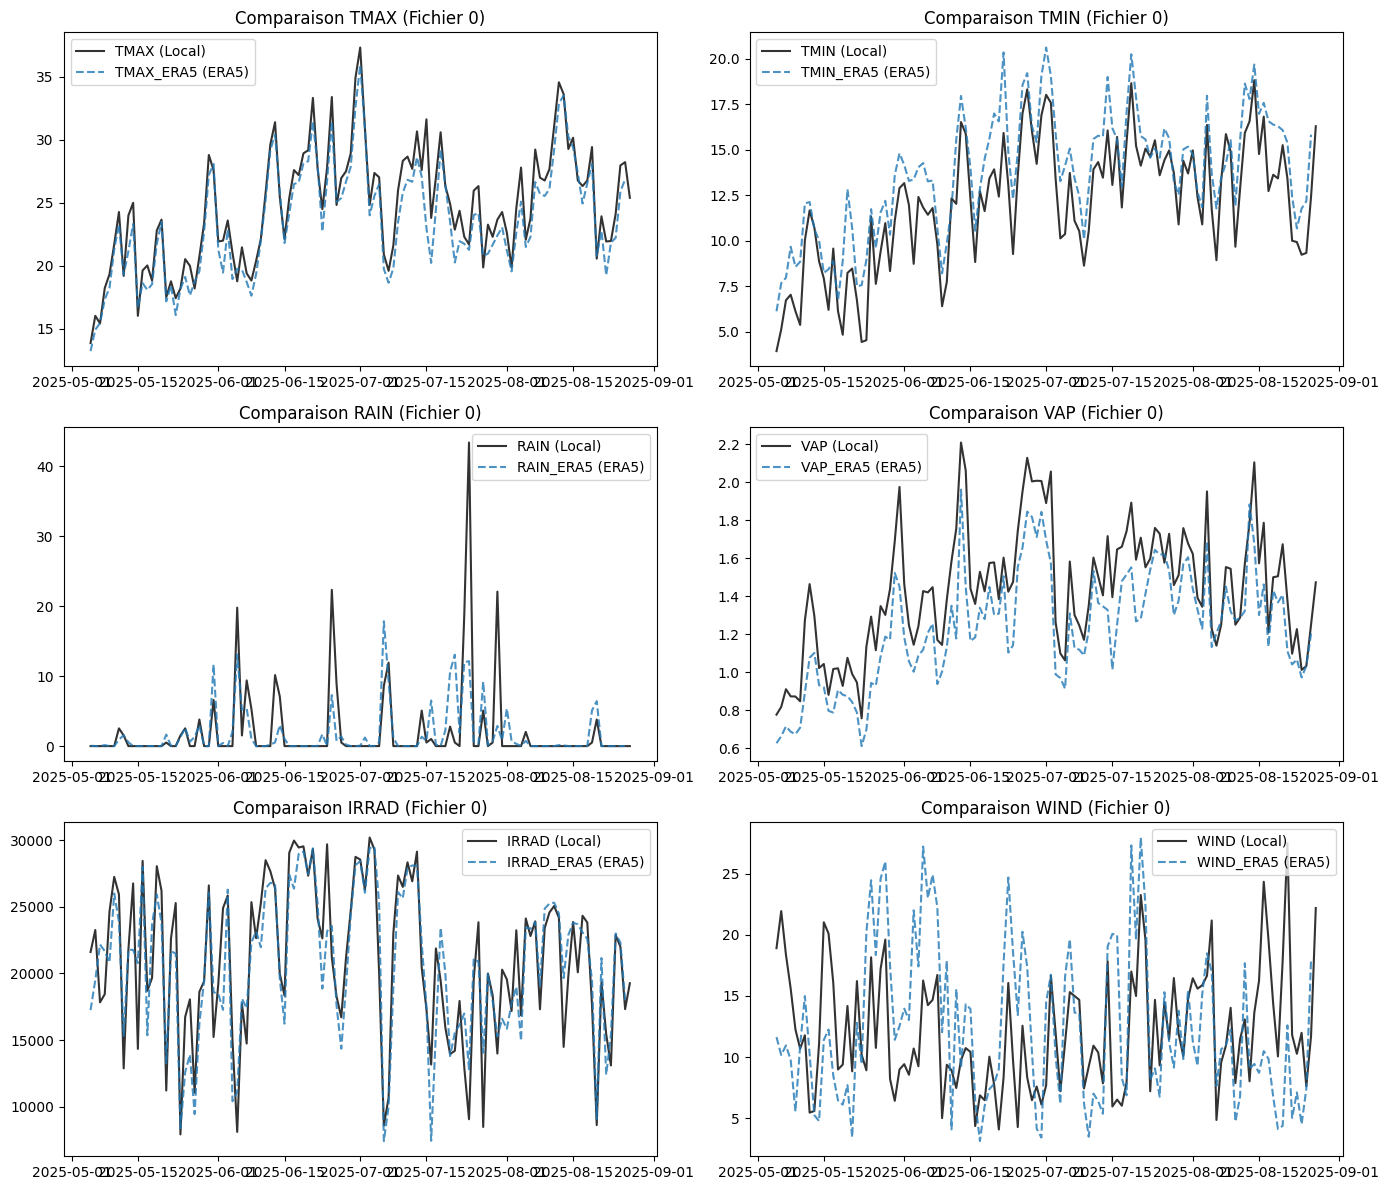

Téléchargement des données ERA5 de 2025-05-05 à 2025-08-27 pour 49.25, 2.7 ...

--- Comparaison (115 jours en commun pour Fichier 1) ---
• TMAX:  RMSE = 1.63 | MAE = 1.26 | Biais = 1.15 (Local - ERA5)
• TMIN:  RMSE = 2.14 | MAE = 1.84 | Biais = -1.77 (Local - ERA5)
• RAIN:  RMSE = 4.57 | MAE = 1.77 | Biais = 0.33 (Local - ERA5)
• VAP:  RMSE = 0.23 | MAE = 0.20 | Biais = 0.19 (Local - ERA5)
• IRRAD:  RMSE = 2732.10 | MAE = 2082.98 | Biais = 393.35 (Local - ERA5)
• WIND:  RMSE = 6.28 | MAE = 5.16 | Biais = -0.38 (Local - ERA5)


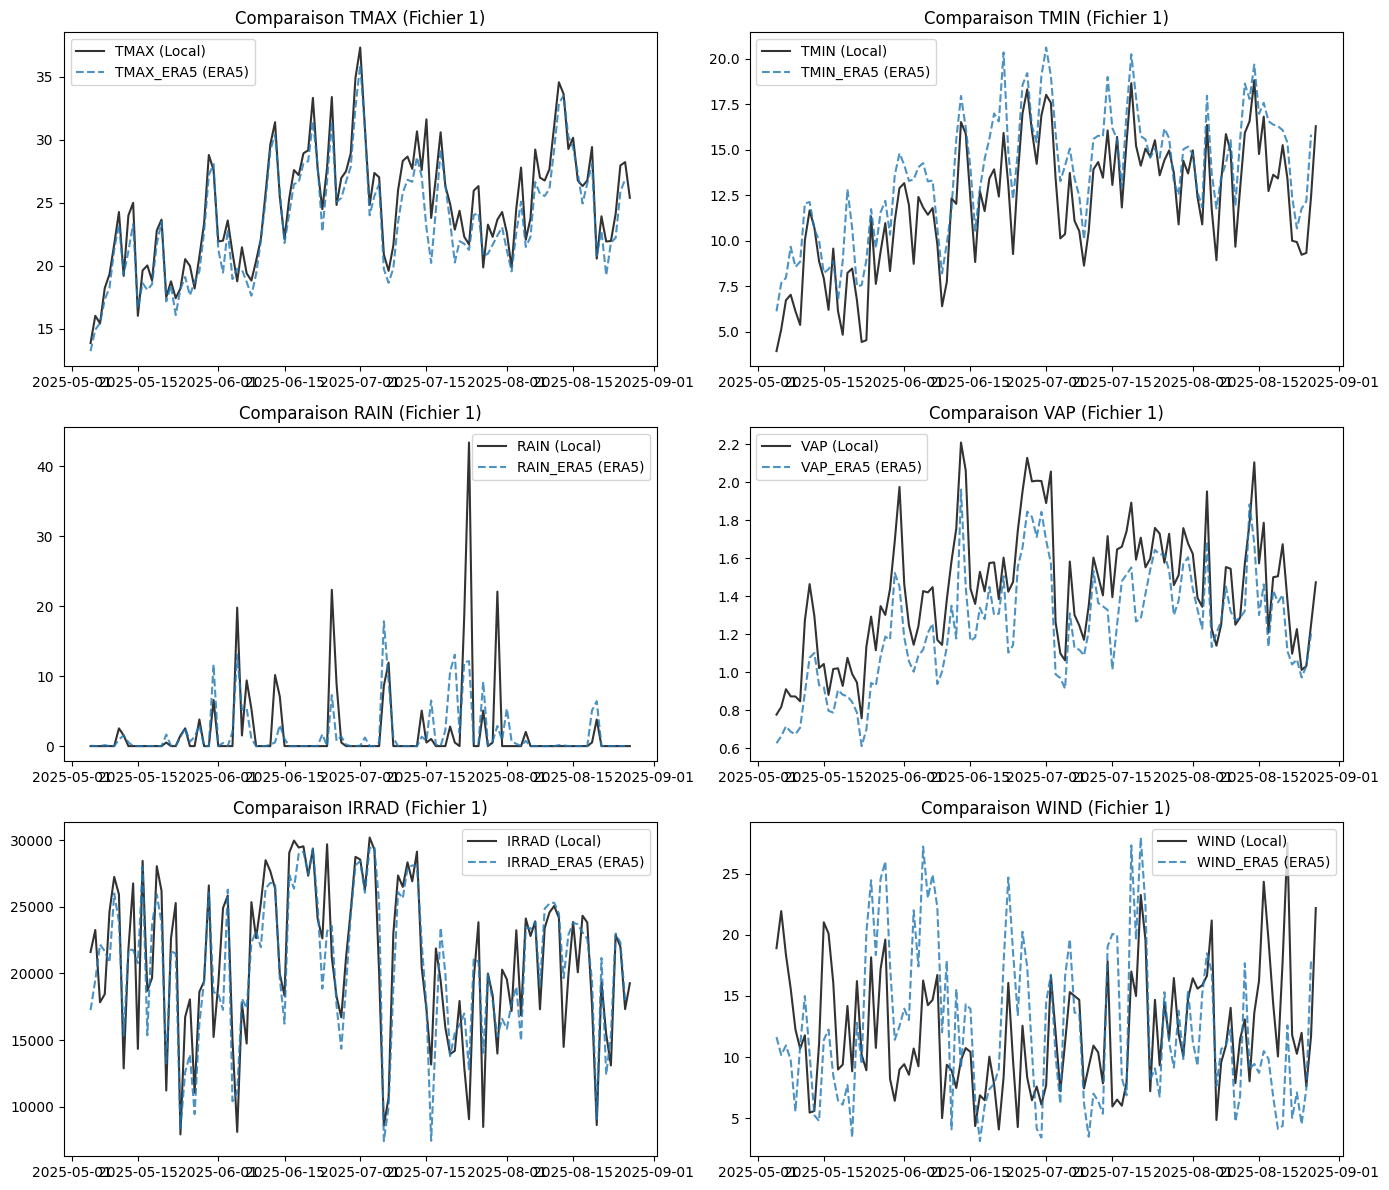

Téléchargement des données ERA5 de 2025-05-07 à 2025-08-27 pour 49.25, 2.7 ...

--- Comparaison (113 jours en commun pour Fichier 2) ---
• TMAX:  RMSE = 1.64 | MAE = 1.27 | Biais = 1.15 (Local - ERA5)
• TMIN:  RMSE = 2.14 | MAE = 1.83 | Biais = -1.76 (Local - ERA5)
• RAIN:  RMSE = 4.61 | MAE = 1.80 | Biais = 0.33 (Local - ERA5)
• VAP:  RMSE = 0.23 | MAE = 0.20 | Biais = 0.19 (Local - ERA5)
• IRRAD:  RMSE = 2702.43 | MAE = 2047.85 | Biais = 328.05 (Local - ERA5)
• WIND:  RMSE = 6.20 | MAE = 5.08 | Biais = -0.56 (Local - ERA5)


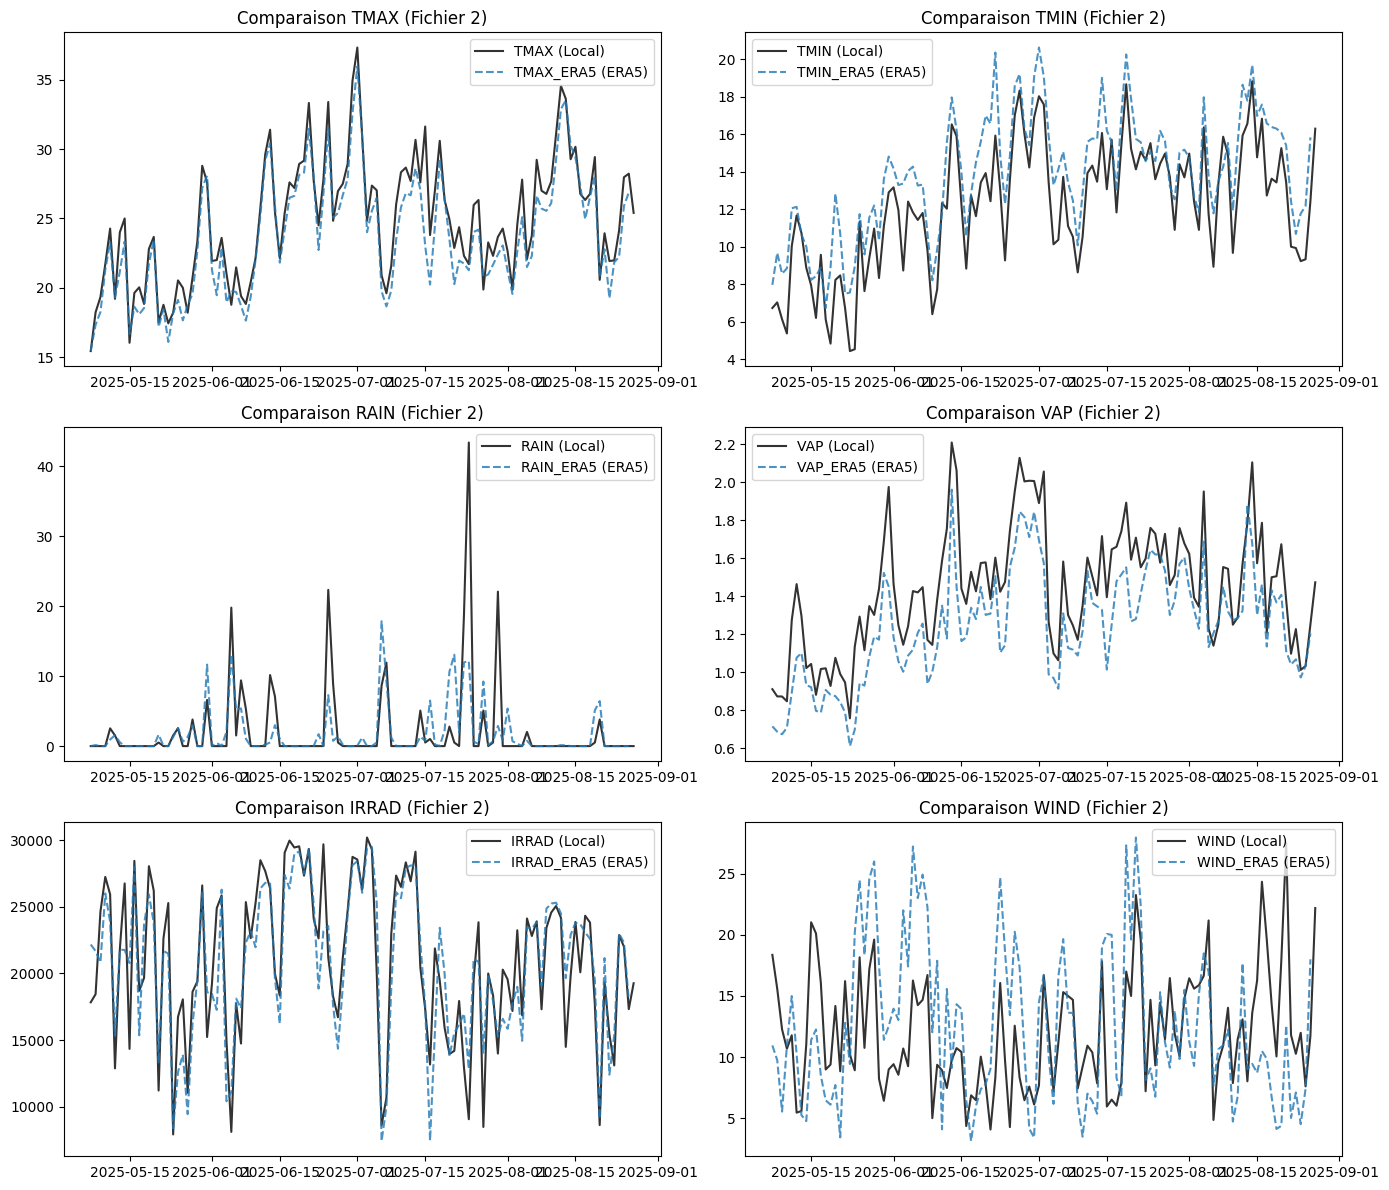

Téléchargement des données ERA5 de 2025-05-05 à 2025-08-27 pour 49.25, 2.7 ...

--- Comparaison (115 jours en commun pour Fichier 3) ---
• TMAX:  RMSE = 1.63 | MAE = 1.26 | Biais = 1.15 (Local - ERA5)
• TMIN:  RMSE = 2.14 | MAE = 1.84 | Biais = -1.77 (Local - ERA5)
• RAIN:  RMSE = 4.57 | MAE = 1.77 | Biais = 0.33 (Local - ERA5)
• VAP:  RMSE = 0.23 | MAE = 0.20 | Biais = 0.19 (Local - ERA5)
• IRRAD:  RMSE = 2732.10 | MAE = 2082.98 | Biais = 393.35 (Local - ERA5)
• WIND:  RMSE = 6.28 | MAE = 5.16 | Biais = -0.38 (Local - ERA5)


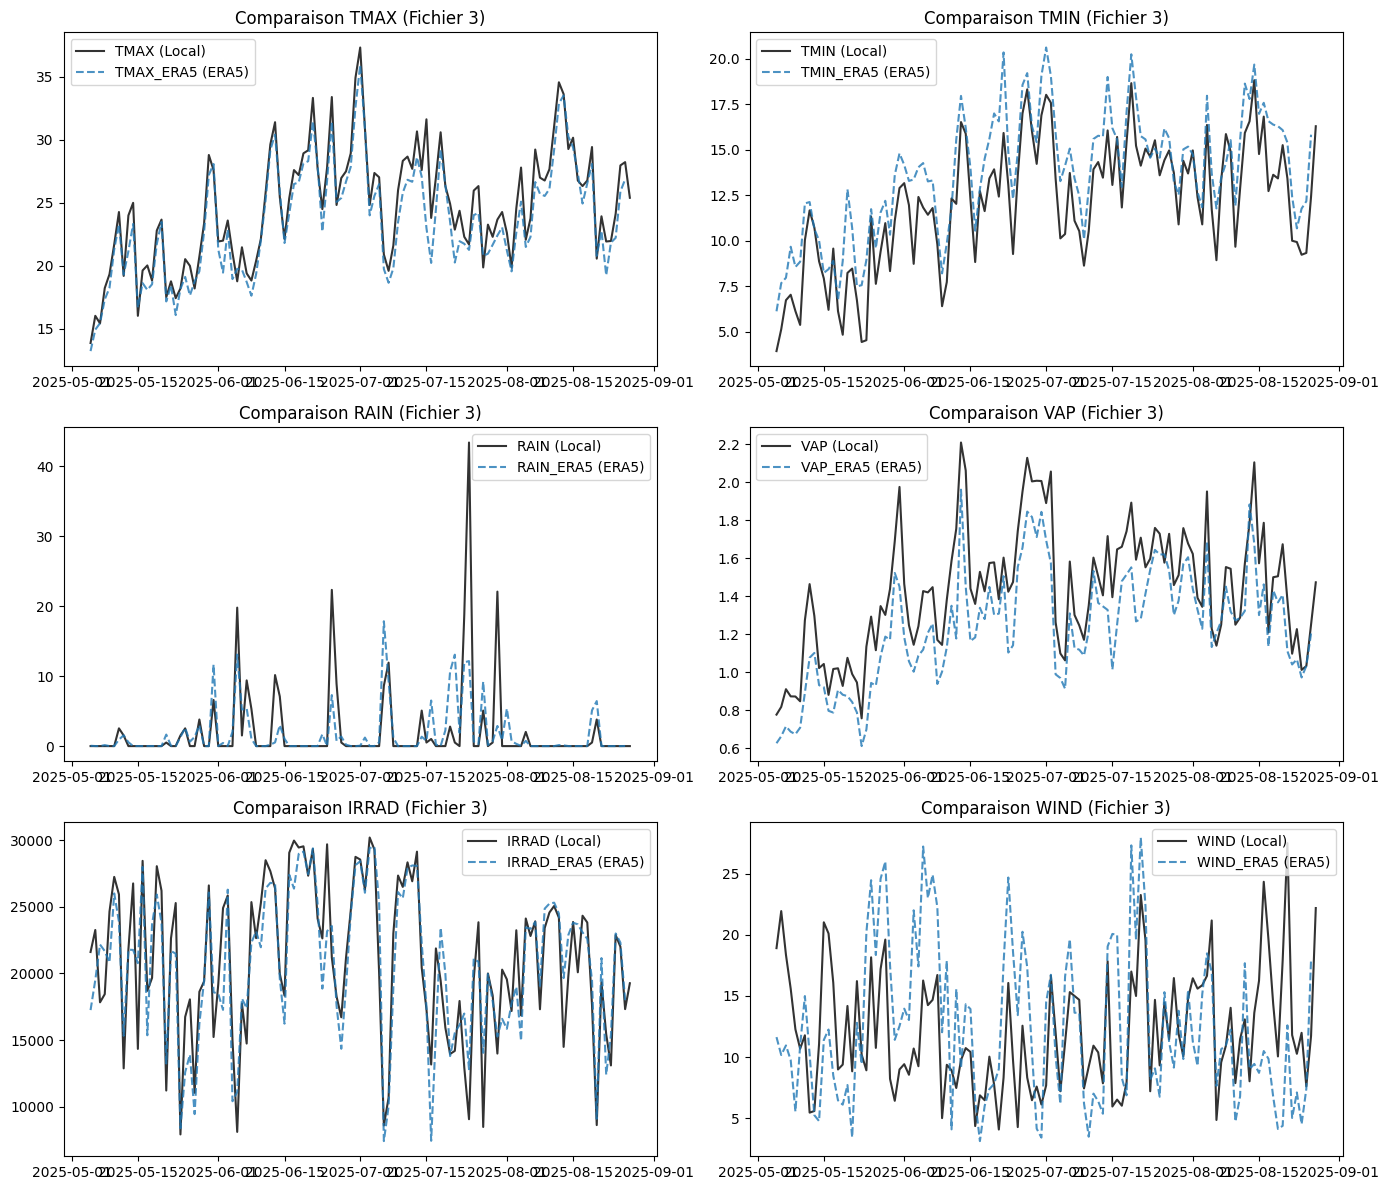

Téléchargement des données ERA5 de 2025-05-05 à 2025-08-28 pour 49.25, 2.7 ...

--- Comparaison (116 jours en commun pour Fichier 4) ---
• TMAX:  RMSE = 1.62 | MAE = 1.25 | Biais = 1.14 (Local - ERA5)
• TMIN:  RMSE = 2.13 | MAE = 1.83 | Biais = -1.75 (Local - ERA5)
• RAIN:  RMSE = 4.55 | MAE = 1.76 | Biais = 0.32 (Local - ERA5)
• VAP:  RMSE = 0.23 | MAE = 0.20 | Biais = 0.20 (Local - ERA5)
• IRRAD:  RMSE = 2732.09 | MAE = 2088.62 | Biais = 413.68 (Local - ERA5)
• WIND:  RMSE = 6.27 | MAE = 5.16 | Biais = -0.33 (Local - ERA5)


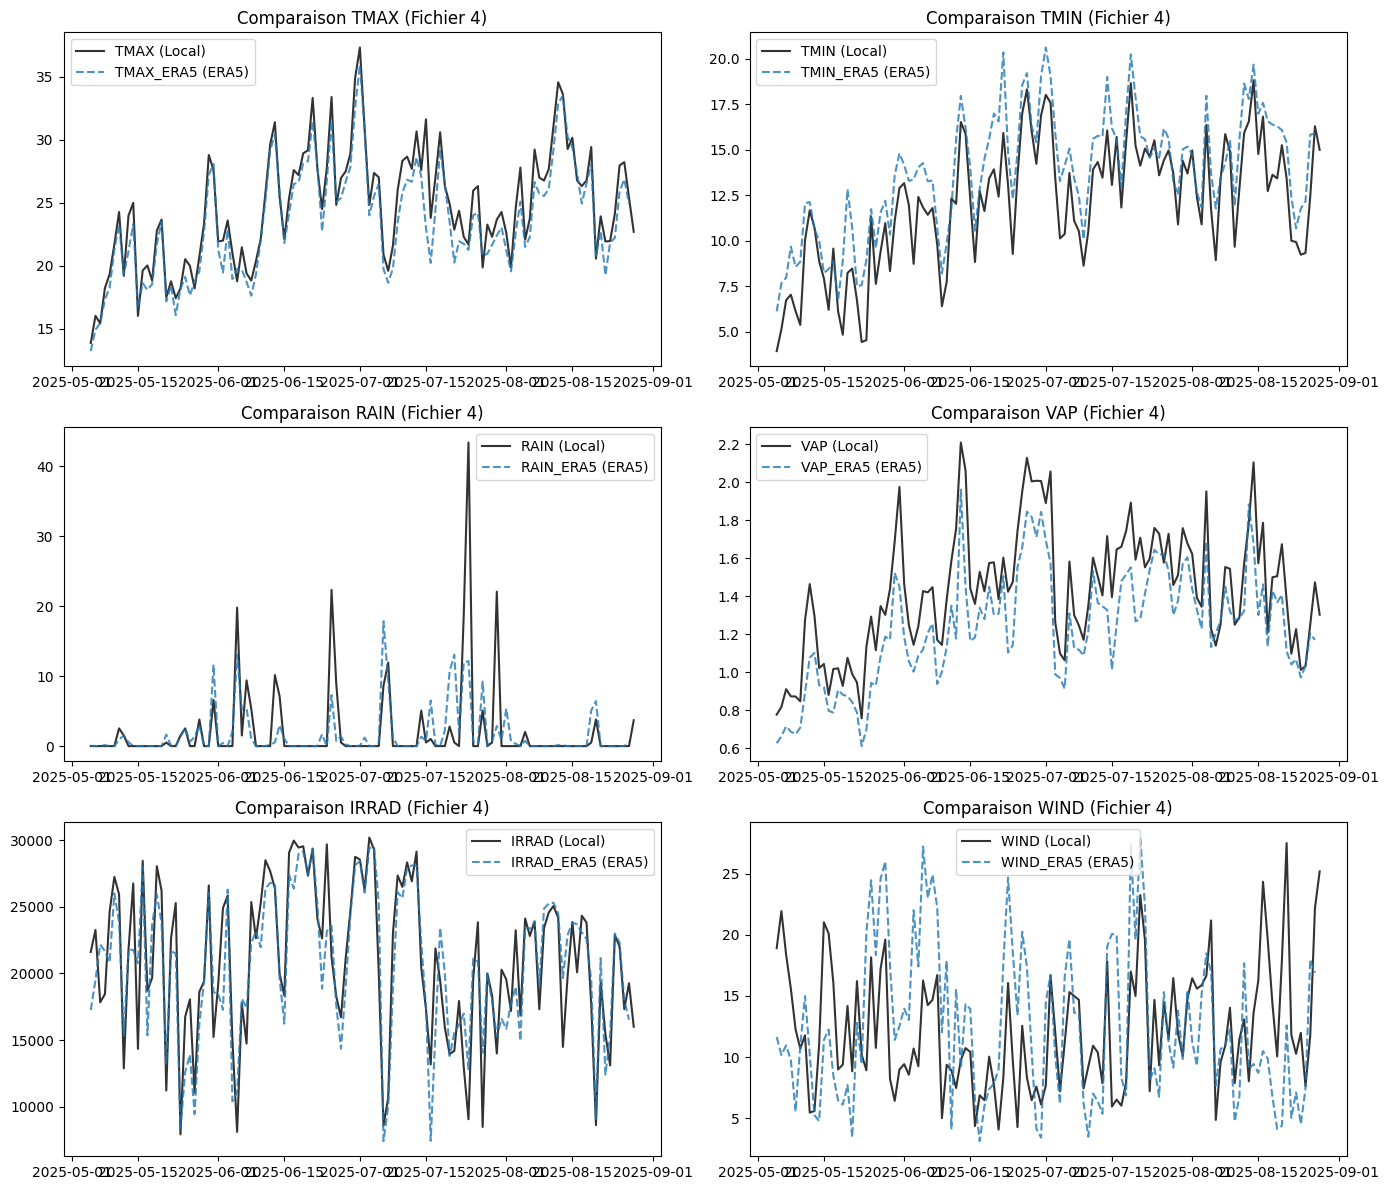

Téléchargement des données ERA5 de 2025-05-05 à 2025-08-27 pour 49.25, 2.7 ...

--- Comparaison (115 jours en commun pour Fichier 5) ---
• TMAX:  RMSE = 1.63 | MAE = 1.26 | Biais = 1.15 (Local - ERA5)
• TMIN:  RMSE = 2.14 | MAE = 1.84 | Biais = -1.77 (Local - ERA5)
• RAIN:  RMSE = 4.57 | MAE = 1.77 | Biais = 0.33 (Local - ERA5)
• VAP:  RMSE = 0.23 | MAE = 0.20 | Biais = 0.19 (Local - ERA5)
• IRRAD:  RMSE = 2732.10 | MAE = 2082.98 | Biais = 393.35 (Local - ERA5)
• WIND:  RMSE = 6.28 | MAE = 5.16 | Biais = -0.38 (Local - ERA5)


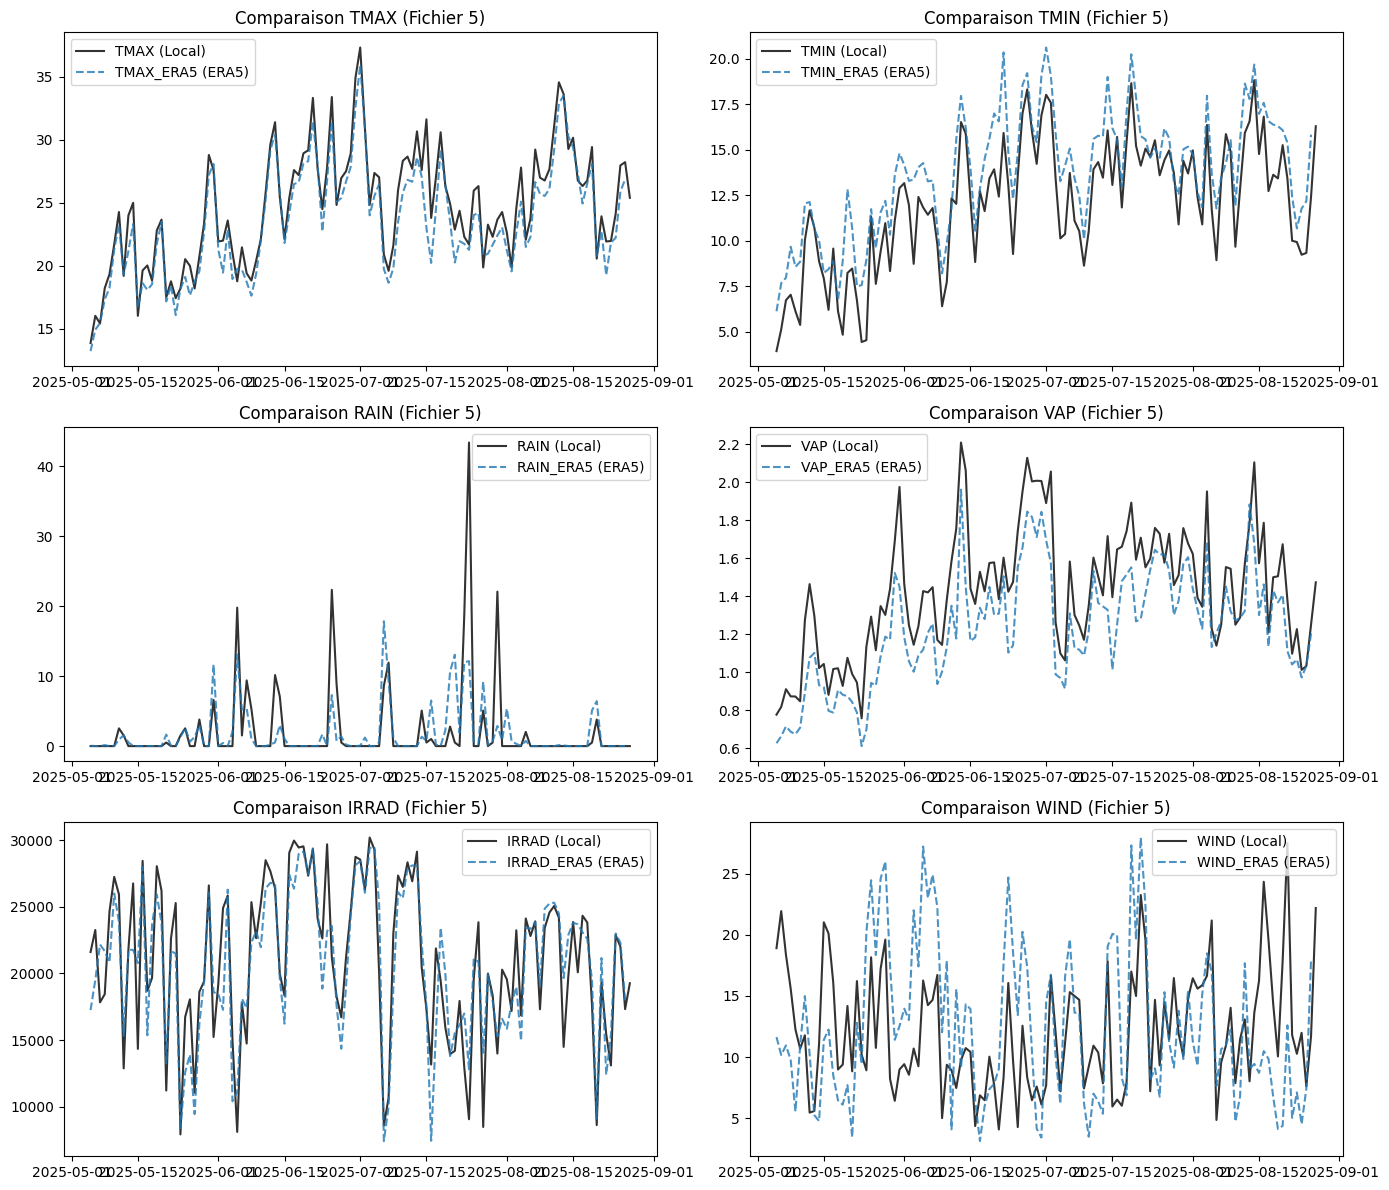


Evaluation Grandvillers : D=0.1, LB=7, H=7, NB=500, Modèle=lstm
Dossier du bloc exploité: trial_0 -> /content/gdrive/MyDrive/NIFA_Download/outputs/csv_meteo_and_soil/test_pca/depth_0.1/lookback_7/horizon_7/nbwindows_500/model_lstm/trial_0



/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


KeyError: "['clay_m_30m_0cm_30cm', 'silt_m_30m_0cm_30cm', 'bulk_m_30m_0cm_30cm', 'ksat_m_1km_0cm', 'dem_aspect', 'dem_twi'] not in index"

In [26]:


# ============================================================
# TEST ON GRANDVILLERS DATA WITH GRANDVILLERS DATASET
# ============================================================

# Réinitialiser les colonnes de features pour les tests (avec RAIN)
TARGET_COL = "soil_moisture"
DATE_COL = "DateTime"

# 1. Charger les données de test Grandvillers
project_path = '/content/gdrive/My Drive/Grandvillers/Grandvillers/soil_moisture_daily'
test_list_local = Get_Grandvillers_data(project_path)

# 2. Préparer directement la version de test ERA5 pour chaque fichier
test_list_era5 = []
print("--- PRÉPARATION DU JEU DE TEST ERA5 ---")
for i, df in enumerate(test_list_local):
    df_substituted = prepare_era5_dataset(df, display_name=f"Fichier {i}")
    test_list_era5.append(df_substituted)

# ============================================================
# 3. Itérer sur chaque modèle entrainé et l'évaluer en comparaison
# ============================================================

c = 0  # On teste par défaut le premier bloc validé croisé de chaque modèle (chunk_0)

for depth in DEPTHS:
    for lookback in LOOKBACK:
        for horizon in HORIZONS:
            for nb_window in NB_WINDOWS : 
                for m in MODELS:
                    
                    # Mise à jour du chemin pour suivre l'architecture "Spatial Block Cross-Validation"
                    model_dir = os.path.join(drive_dir, f"depth_{depth}", f"lookback_{lookback}", f"horizon_{horizon}", f"nbwindows_{nb_window}", f"model_{m}", f"trial_{c}")

                    if not os.path.exists(model_dir):
                        print(f"Model directory not found: {model_dir}")
                        continue

                    print(f"\n=======================================================")
                    print(f"Evaluation Grandvillers : D={depth}, LB={lookback}, H={horizon}, NB={nb_window}, Modèle={m}")
                    print(f"Dossier du bloc exploité: trial_{c} -> {model_dir}")
                    print(f"=======================================================\n")

                    model, scaler_x, scaler_y = load_saved_model_and_scalers(
                        model_dir, 
                        m, 
                        lookback, 
                        horizon, 
                        len(FEATURE_COLS)
                    )
                    
                    if model is None:
                        continue
                    
                    run_comparative_evaluation(
                        model, scaler_x, scaler_y, 
                        test_list_local, test_list_era5, 
                        model_dir, 
                        lookback, 
                        horizon, 
                        depth,
                        nb_windows=nb_window,
                        chunk=c,
                        model_name=m
                    )

In [29]:
import ipywidgets as widgets
from IPython.display import display
# ── Configuration ──────────────────────────────────────────
COL_X   = "nb_windows"
COL_Y   = "value"
EXCLUDE = ["timestamp", "chunk", "notes", "file_id"]
# ── Construction des widgets de filtre ──────────────────────
def build_filters():
    df_temp = pd.read_csv(RESULTS_CSV_PATH)
    params = [
        c for c in df_temp.columns
        if c not in [COL_X, COL_Y] + EXCLUDE
        and df_temp[c].nunique() > 1
        and not df_temp[c].isna().all()
    ]
    filtres = {}
    for col in params:
        valeurs = ["Tous"]
        if df_temp[col].isna().any():
            valeurs.append("NaN")
        valeurs += sorted(df_temp[col].dropna().unique().tolist(), key=str)
        filtres[col] = widgets.SelectMultiple(
            options=valeurs,
            value=["Tous"],
            description=col,
            layout=widgets.Layout(width="500px", height="120px")
        )
    return filtres, params
filtres, PARAMS = build_filters()
btn = widgets.Button(description="Mettre à jour", button_style="primary")
output = widgets.Output()
def tracer(b):
    with output:
        output.clear_output(wait=True)
        # ← Recharge le CSV à chaque clic
        df = pd.read_csv(RESULTS_CSV_PATH)
        masque = pd.Series([True] * len(df), index=df.index)
        for col, w in filtres.items():
            sel = list(w.value)
            if "Tous" not in sel:
                col_mask = pd.Series([False] * len(df), index=df.index)
                if "NaN" in sel:
                    col_mask |= df[col].isna()
                    autres = [v for v in sel if v != "NaN"]
                    if autres:
                        col_mask |= df[col].isin(autres)
                else:
                    col_mask = df[col].isin(sel)
                masque &= col_mask
        sous_df = df[masque].copy()
        cols_var = [c for c in PARAMS if c in sous_df.columns and sous_df[c].nunique() > 1]
        sous_df["_combo"] = sous_df[cols_var].apply(
            lambda r: " | ".join(f"{k}={v}" for k, v in zip(cols_var, r)), axis=1
        )
        # ── Figure avec espace réservé pour la légende ──
        fig, ax = plt.subplots(figsize=(20, 12))
        fig.subplots_adjust(right=0.70)   # 30% à droite pour la légende
        for label, grp in sous_df.groupby("_combo"):
            g = grp.sort_values(COL_X)
            ax.plot(g[COL_X], g[COL_Y], label=label,
                    marker='o', markersize=5, linewidth=1.5, alpha=0.75)
        ax.set_xlabel(COL_X)
        ax.set_ylabel(COL_Y)
        ax.set_title(f"{COL_Y} vs {COL_X} — {len(sous_df)} points filtrés")
        ax.legend(
            title="Paramètres",
            bbox_to_anchor=(1.02, 1), loc="upper left",
            frameon=True, fancybox=False
        )
        plt.show()
btn.on_click(tracer)
ui = widgets.HBox(list(filtres.values()))
display(ui, btn, output)
tracer(None)

Button(button_style='primary', description='Mettre à jour', style=ButtonStyle())

Output()